

# Hypothesis:

 We hypothesise that an inverted US yield curve, meaning 10Y yield - 2Y yield < 0,
 predicts weaker or negative Hang Seng Index returns over the following 1-3 months.


 # Economic reasoning:

 A yield curve inversion often reflects tight monetary policy, recession fears,
 and weaker future growth expectations. Since Hong Kong / China-linked equities
 are sensitive to global risk appetite, capital flows, USD funding conditions,
 and export demand, an inverted US yield curve may be a warning signal for
 weaker future HSI returns.




In [ ]:
#Data Checking & Visualisation

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -----------------------------
# 1. Set project parameters
# -----------------------------

start_date = "2000-01-01"

# FRED tickers:
# DGS2 = US 2-Year Treasury yield
# DGS10 = US 10-Year Treasury yield
fred_2y_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS2"
fred_10y_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10"

# HSI ticker on Yahoo Finance
hsi_ticker = "^HSI"

# -----------------------------
# 2. Download US yield data from FRED
# -----------------------------

# read_csv pulls the data directly from FRED.
# The DATE column becomes our time index.
us_2y = pd.read_csv(fred_2y_url)
us_10y = pd.read_csv(fred_10y_url)

# Rename columns clearly.
us_2y.columns = ["date", "us_2y_yield"]
us_10y.columns = ["date", "us_10y_yield"]

# Convert date column to datetime format.
us_2y["date"] = pd.to_datetime(us_2y["date"])
us_10y["date"] = pd.to_datetime(us_10y["date"])

# Set date as index.
us_2y = us_2y.set_index("date")
us_10y = us_10y.set_index("date")

# FRED sometimes uses "." for missing values.
# Convert columns to numeric and force bad values into NaN.
us_2y["us_2y_yield"] = pd.to_numeric(us_2y["us_2y_yield"], errors="coerce")
us_10y["us_10y_yield"] = pd.to_numeric(us_10y["us_10y_yield"], errors="coerce")

# Keep only data after start_date.
us_2y = us_2y.loc[start_date:]
us_10y = us_10y.loc[start_date:]

# -----------------------------
# 3. Download HSI price data
# -----------------------------

hsi_price = yf.download(
    hsi_ticker,
    start=start_date,
    auto_adjust=True
)["Close"]

# Sometimes yfinance returns a DataFrame instead of a Series.
# This makes sure we get one clean price series.
if isinstance(hsi_price, pd.DataFrame):
    hsi_price = hsi_price.iloc[:, 0]

hsi_price = hsi_price.dropna()
hsi_price.name = "hsi_price"

# -----------------------------
# 4. Convert everything to monthly frequency
# -----------------------------

# Why monthly?
# Our project asks whether the yield curve predicts HSI returns over the next
# 1-3 months, so monthly data is cleaner than daily data for this question.

# For yields, we take the last available observation of each month.
monthly_2y = us_2y.resample("ME").last()
monthly_10y = us_10y.resample("ME").last()

# For HSI, we take the last closing price of each month.
monthly_hsi_price = hsi_price.resample("ME").last()

# HSI monthly return:
# Percentage change from one month-end price to the next month-end price.
monthly_hsi_return = monthly_hsi_price.pct_change()
monthly_hsi_return.name = "hsi_monthly_return"

# -----------------------------
# 5. Combine into one clean dataframe
# -----------------------------

data = pd.concat(
    [
        monthly_2y,
        monthly_10y,
        monthly_hsi_price,
        monthly_hsi_return
    ],
    axis=1
)

# Yield curve spread:
# 10-year yield minus 2-year yield.
# Positive spread = normal yield curve.
# Negative spread = inverted yield curve.
data["yield_curve_spread"] = data["us_10y_yield"] - data["us_2y_yield"]

# Inversion indicator:
# 1 means inverted curve.
# 0 means normal curve.
data["inverted_curve"] = np.where(data["yield_curve_spread"] < 0, 1, 0)

# Drop rows with missing values.
# Missing values can happen because markets have holidays or some series start later.
data = data.dropna()

# -----------------------------
# 6. Reorder columns neatly
# -----------------------------

data = data[
    [
        "us_2y_yield",
        "us_10y_yield",
        "yield_curve_spread",
        "inverted_curve",
        "hsi_price",
        "hsi_monthly_return"
    ]
]

# -----------------------------
# 7. Basic data checks
# -----------------------------

print("DATASET BUILT")
print("-" * 50)

print("Rows:", len(data))
print("Start date:", data.index.min())
print("End date:", data.index.max())

print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isna().sum())

print("\nLatest 5 rows:")
print(data.tail())

print("\nInverted curve months:")
print(data["inverted_curve"].value_counts())

print("\nSummary statistics:")
print(data.describe().round(4))

# -----------------------------
# 8. Exploratory plot: US yields
# -----------------------------

plt.figure(figsize=(14, 6))

plt.plot(data.index, data["us_2y_yield"], label="US 2Y Yield", color="blue")
plt.plot(data.index, data["us_10y_yield"], label="US 10Y Yield", color="red")

plt.title("US 2Y and 10Y Treasury Yields")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 9. Exploratory plot: yield curve spread
# -----------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    data.index,
    data["yield_curve_spread"],
    label="Yield Curve Spread: 10Y - 2Y",
    color="purple"
)

# Zero line:
# Below zero means the yield curve is inverted.
plt.axhline(0, color="black", linestyle="--", label="Zero Line")

plt.title("US Yield Curve Spread")
plt.xlabel("Date")
plt.ylabel("Spread (%)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 10. Exploratory plot: HSI price
# -----------------------------

plt.figure(figsize=(14, 6))

plt.plot(data.index, data["hsi_price"], label="HSI Price", color="black")

plt.title("Hang Seng Index Monthly Price")
plt.xlabel("Date")
plt.ylabel("HSI Level")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 11. Exploratory plot: HSI monthly returns
# -----------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    data.index,
    data["hsi_monthly_return"],
    label="HSI Monthly Return",
    color="green"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("HSI Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 12. Quick first-look relationship plot
# -----------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    data["yield_curve_spread"],
    data["hsi_monthly_return"],
    alpha=0.6
)

plt.axvline(0, color="black", linestyle="--", label="Inversion Threshold")
plt.axhline(0, color="red", linestyle="--")

plt.title("Yield Curve Spread vs Same-Month HSI Return")
plt.xlabel("Yield Curve Spread: 10Y - 2Y")
plt.ylabel("HSI Monthly Return")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 13. Store clean dataset object
# -----------------------------

# This is the main dataframe we will use.
# It is already:
# - monthly
# - date-indexed
# - cleaned
# - aligned
# - labelled clearly
clean_macro_data = data.copy()

print("\nClean dataframe is stored as: clean_macro_data")

In [ ]:
# Goal:

# Transform raw macro/market data into model-ready features.

# We will create:

# 1. Yield curve level
# 2. Yield curve slope
# 3. Yield curve change
# 4. Lagged yield curve variables
# 5. Inversion regime indicators
# 6. HSI high-volatility regime
# 7. Interaction terms
# 8. Forward HSI returns for future prediction
# 9. Stationarity checks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# -----------------------------
# 1. Start from previous dataset
# -----------------------------

df = clean_macro_data.copy()

# -----------------------------
# 2. Yield curve level
# -----------------------------

# Yield curve level:
# A simple proxy for the general level of interest rates.
# Here we use the average of the 2Y and 10Y yields.
#
# Example:
# 2Y = 4%, 10Y = 5%
# level = (4 + 5) / 2 = 4.5%
df["yield_curve_level"] = (
    df["us_2y_yield"] + df["us_10y_yield"]
) / 2

# -----------------------------
# 3. Yield curve slope
# -----------------------------

# Yield curve slope:
# This is the same as our spread:
# 10Y yield minus 2Y yield.
#
# Positive slope = normal curve.
# Negative slope = inverted curve.
df["yield_curve_slope"] = (
    df["us_10y_yield"] - df["us_2y_yield"]
)

# -----------------------------
# 4. Yield curve change
# -----------------------------

# Yield curve change:
# How much the slope changed from last month to this month.
#
# If this is negative, the curve flattened.
# If this is positive, the curve steepened.
df["yield_curve_change_1m"] = df["yield_curve_slope"].diff(1)

# -----------------------------
# 5. Lagged variables
# -----------------------------

# Lagged variables:
# These are past values of the signal.
#
# Why?
# Because we want to test whether the yield curve from 1, 3, or 6 months ago
# predicts future HSI returns.
#
# shift(1) means "use last month's value."
# shift(3) means "use the value from 3 months ago."
# shift(6) means "use the value from 6 months ago."
df["spread_lag_1m"] = df["yield_curve_slope"].shift(1)
df["spread_lag_3m"] = df["yield_curve_slope"].shift(3)
df["spread_lag_6m"] = df["yield_curve_slope"].shift(6)

df["level_lag_1m"] = df["yield_curve_level"].shift(1)
df["change_lag_1m"] = df["yield_curve_change_1m"].shift(1)

# -----------------------------
# 6. Regime indicator
# -----------------------------

# Regime indicator:
# A binary variable that marks whether the yield curve is inverted.
#
# 1 = inverted curve
# 0 = normal curve
df["is_inverted"] = np.where(df["yield_curve_slope"] < 0, 1, 0)

# We also create lagged inversion indicators.
# These answer:
# Was the curve inverted 1, 3, or 6 months ago?
df["is_inverted_lag_1m"] = df["is_inverted"].shift(1)
df["is_inverted_lag_3m"] = df["is_inverted"].shift(3)
df["is_inverted_lag_6m"] = df["is_inverted"].shift(6)

# -----------------------------
# 7. HSI high-volatility regime
# -----------------------------

# High-volatility regime:
# We calculate 6-month rolling volatility of HSI monthly returns.
#
# Rolling volatility means:
# "How volatile were HSI monthly returns over the recent past?"
#
# We annualize monthly volatility by multiplying by sqrt(12),
# because there are 12 months in a year.
df["hsi_rolling_vol_6m"] = (
    df["hsi_monthly_return"].rolling(6).std() * np.sqrt(12)
)

# Median volatility threshold:
# If HSI volatility is above its historical median, call it high-vol.
vol_threshold = df["hsi_rolling_vol_6m"].median()

df["hsi_high_vol_regime"] = np.where(
    df["hsi_rolling_vol_6m"] > vol_threshold,
    1,
    0
)

# -----------------------------
# 8. Interaction terms
# -----------------------------

# Interaction term:
# A variable that combines two conditions.
#
# Question:
# Does yield curve inversion matter more during high-volatility HSI regimes?
#
# If both are true:
# is_inverted = 1
# hsi_high_vol_regime = 1
#
# Then interaction = 1.
# Otherwise interaction = 0.
df["inverted_x_high_vol"] = (
    df["is_inverted"] * df["hsi_high_vol_regime"]
)

# Another interaction:
# Does the continuous spread matter differently during high-vol regimes?
df["spread_x_high_vol"] = (
    df["yield_curve_slope"] * df["hsi_high_vol_regime"]
)

# -----------------------------
# 9. Forward HSI returns
# -----------------------------

# Forward return:
# The return AFTER the current signal.
#
# We need this because we want to predict future HSI returns.
#
# hsi_forward_return_1m:
# Next month's HSI return.
#
# hsi_forward_return_3m:
# Total HSI return over the next 3 months.
#
# hsi_forward_return_6m:
# Total HSI return over the next 6 months.
df["hsi_forward_return_1m"] = df["hsi_monthly_return"].shift(-1)

df["hsi_forward_return_3m"] = (
    (1 + df["hsi_monthly_return"]).shift(-1).rolling(3).apply(np.prod, raw=True) - 1
)

df["hsi_forward_return_6m"] = (
    (1 + df["hsi_monthly_return"]).shift(-1).rolling(6).apply(np.prod, raw=True) - 1
)

# IMPORTANT NOTE:
# For forward returns, we are intentionally using future returns as the target variable.
# This is okay for research labels.
# But we must never use future returns as trading signals.

# -----------------------------
# 10. Clean model dataset
# -----------------------------

feature_data = df.dropna().copy()

# -----------------------------
# 11. Stationarity check function
# -----------------------------

def run_adf_test(series, name):
    """
    ADF test = Augmented Dickey-Fuller test.

    Purpose:
    It checks whether a time series is stationary.

    Stationary means:
    The series has a relatively stable mean and variance over time.

    Why this matters:
    Many regression models behave better when inputs are stationary.

    Null hypothesis:
    The series is non-stationary.

    If p-value < 0.05:
    We reject non-stationarity and treat the series as likely stationary.
    """

    result = adfuller(series.dropna())

    adf_statistic = result[0]
    p_value = result[1]

    print(f"\nADF Test: {name}")
    print("-" * 40)
    print(f"ADF statistic: {adf_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Conclusion: Likely stationary.")
    else:
        print("Conclusion: May be non-stationary.")

# -----------------------------
# 12. Run stationarity checks
# -----------------------------

features_to_test = [
    "yield_curve_level",
    "yield_curve_slope",
    "yield_curve_change_1m",
    "spread_lag_1m",
    "spread_lag_3m",
    "spread_lag_6m",
    "hsi_monthly_return",
    "hsi_rolling_vol_6m"
]

print("STATIONARITY CHECKS")
print("=" * 50)

for col in features_to_test:
    run_adf_test(feature_data[col], col)

# -----------------------------
# 13. Feature summary
# -----------------------------

print("\nFEATURE DATASET BUILT")
print("=" * 50)

print("Rows:", len(feature_data))
print("Start date:", feature_data.index.min())
print("End date:", feature_data.index.max())

print("\nColumns:")
print(feature_data.columns.tolist())

print("\nLatest 5 rows:")
print(feature_data.tail())

print("\nRegime counts:")
print("Inverted curve:")
print(feature_data["is_inverted"].value_counts())

print("\nHSI high-volatility regime:")
print(feature_data["hsi_high_vol_regime"].value_counts())

print("\nSummary statistics for selected features:")
selected_features = [
    "yield_curve_level",
    "yield_curve_slope",
    "yield_curve_change_1m",
    "spread_lag_1m",
    "spread_lag_3m",
    "spread_lag_6m",
    "is_inverted",
    "hsi_high_vol_regime",
    "inverted_x_high_vol",
    "hsi_forward_return_1m",
    "hsi_forward_return_3m",
    "hsi_forward_return_6m"
]

print(feature_data[selected_features].describe().round(4))

# -----------------------------
# 14. Quick feature plots
# -----------------------------

plt.figure(figsize=(14, 5))
plt.plot(feature_data.index, feature_data["yield_curve_slope"], label="Yield Curve Slope")
plt.axhline(0, color="black", linestyle="--", label="Inversion Line")
plt.title("US Yield Curve Slope: 10Y - 2Y")
plt.xlabel("Date")
plt.ylabel("Spread (%)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(feature_data.index, feature_data["yield_curve_change_1m"], label="1M Change in Yield Curve Slope", color="orange")
plt.axhline(0, color="black", linestyle="--")
plt.title("Monthly Change in Yield Curve Slope")
plt.xlabel("Date")
plt.ylabel("Change in Spread")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(feature_data.index, feature_data["hsi_rolling_vol_6m"], label="HSI 6M Rolling Volatility", color="red")
plt.axhline(vol_threshold, color="black", linestyle="--", label="Median Volatility")
plt.title("HSI High-Volatility Regime Indicator")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 15. Store final feature dataset
# -----------------------------

# This dataframe is what we will use for statistical testing.
macro_feature_data = feature_data.copy()

print("\nFinal feature dataframe is stored as: macro_feature_data")

We transformed the raw macro dataset into model-ready features for testing whether the US yield curve predicts future Hang Seng returns. We created the yield curve level, slope, monthly change, lagged spreads over 1-month, 3-month, and 6-month horizons, inversion indicators, HSI volatility regimes, interaction terms, and forward HSI return targets.

The key economic signal is the yield curve slope, defined as the US 10-year yield minus the US 2-year yield. A negative slope indicates an inverted yield curve, which may reflect tighter monetary policy, recession expectations, and weaker global risk appetite.

We also checked stationarity because non-stationary variables can create misleading statistical relationships. HSI monthly returns and HSI 6-month rolling volatility appeared stationary, meaning they are more suitable for modelling than raw price levels. The engineered dataset is now clean, monthly, date-indexed, and ready for statistical testing.

#**STATISTICAL TESTING**

CORRELATION ANALYSIS
                  target  observations  pearson_corr  pearson_pvalue  \
0  hsi_forward_return_1m           311       -0.0031          0.9564   
1  hsi_forward_return_3m           311       -0.0015          0.9788   
2  hsi_forward_return_6m           311        0.0321          0.5727   

   spearman_corr  spearman_pvalue  
0        -0.0048           0.9329  
1         0.0130           0.8200  
2         0.0180           0.7520  

INTERPRETATION GUIDE

Target: hsi_forward_return_1m
Pearson correlation: -0.0031
P-value: 0.9564
Statistical read: correlation is NOT statistically significant at the 5% level.
Sample direction: negative, but not reliable enough to conclude a real relationship.
Research conclusion: do not treat this as evidence of predictive power.

Target: hsi_forward_return_3m
Pearson correlation: -0.0015
P-value: 0.9788
Statistical read: correlation is NOT statistically significant at the 5% level.
Sample direction: negative, but not reliable enough to 

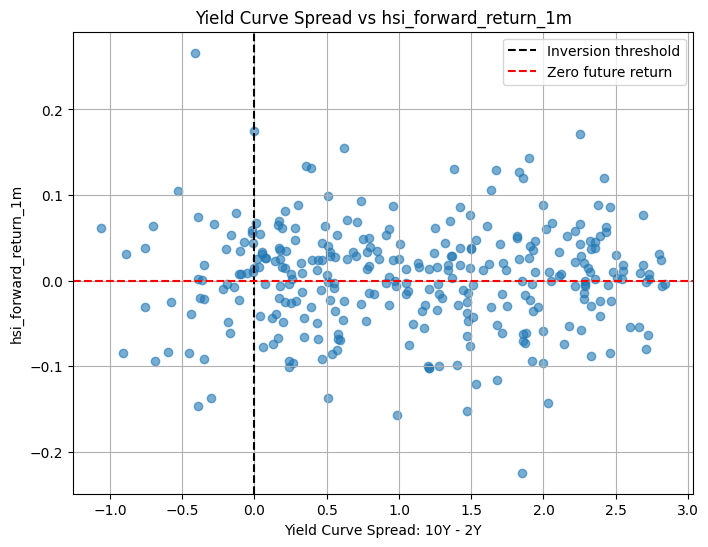

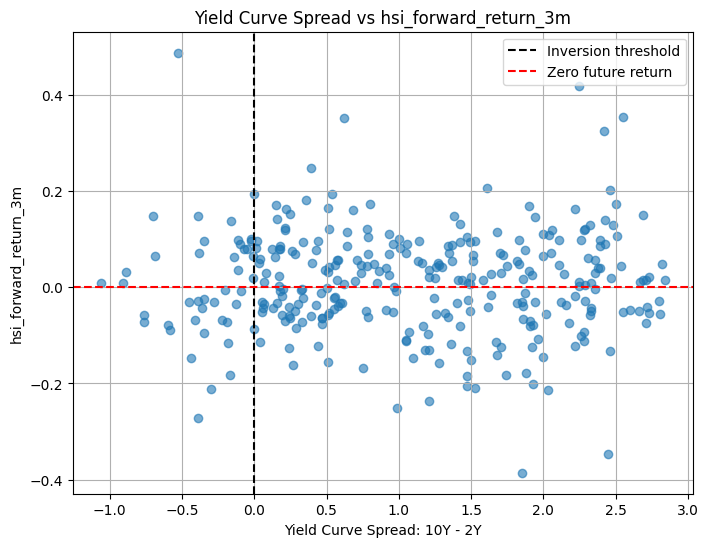

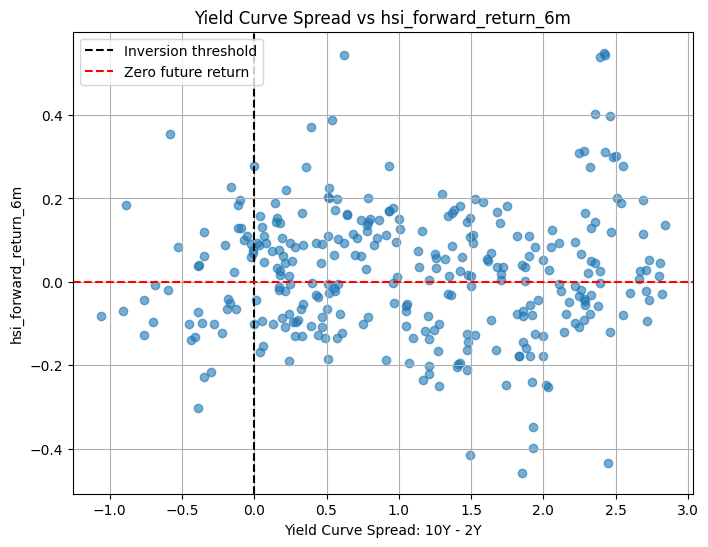

In [4]:

# ============================================================

# Part 1: Correlation Analysis
# Question: Does the US yield curve spread relate to future HSI returns?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# -----------------------------
# 1. Start from previous feature dataset
# -----------------------------

df = macro_feature_data.copy()

# -----------------------------
# 2. Define signal and target variables
# -----------------------------

# Signal:
# yield_curve_slope = US 10Y yield - US 2Y yield.
#
# If this is positive, the yield curve is normal.
# If this is negative, the yield curve is inverted.
signal_col = "yield_curve_slope"

# Targets:
# These are future HSI returns over different horizons.
#
# hsi_forward_return_1m = next month's HSI return.
# hsi_forward_return_3m = HSI return over the next 3 months.
# hsi_forward_return_6m = HSI return over the next 6 months.
target_cols = [
    "hsi_forward_return_1m",
    "hsi_forward_return_3m",
    "hsi_forward_return_6m"
]

# -----------------------------
# 3. Run correlation tests
# -----------------------------

correlation_results = []

for target_col in target_cols:

    # Keep only rows where both signal and target exist.
    test_data = df[[signal_col, target_col]].dropna()

    x = test_data[signal_col]
    y = test_data[target_col]

    # Pearson correlation:
    # Measures linear relationship.
    #
    # Example:
    # If yield spread goes higher and forward returns also tend to go higher,
    # Pearson correlation will be positive.
    pearson_corr, pearson_pvalue = pearsonr(x, y)

    # Spearman correlation:
    # Measures rank relationship.

    # It asks:
    # When yield spread is relatively high compared to other months,
    # are future HSI returns also relatively high?
    #
    # Spearman is useful because financial relationships may not be perfectly linear.
    spearman_corr, spearman_pvalue = spearmanr(x, y)

    correlation_results.append({
        "target": target_col,
        "observations": len(test_data),
        "pearson_corr": pearson_corr,
        "pearson_pvalue": pearson_pvalue,
        "spearman_corr": spearman_corr,
        "spearman_pvalue": spearman_pvalue
    })

# Convert results into a clean table.
correlation_table = pd.DataFrame(correlation_results)

# -----------------------------
# 4. Display results
# -----------------------------

print("CORRELATION ANALYSIS")
print("=" * 60)

display_table = correlation_table.copy()

display_table["pearson_corr"] = display_table["pearson_corr"].round(4)
display_table["pearson_pvalue"] = display_table["pearson_pvalue"].round(4)
display_table["spearman_corr"] = display_table["spearman_corr"].round(4)
display_table["spearman_pvalue"] = display_table["spearman_pvalue"].round(4)

print(display_table)

# -----------------------------
# 5. Simple interpretation helper
# -----------------------------

print("\nINTERPRETATION GUIDE")
print("=" * 60)

for _, row in correlation_table.iterrows():

    target = row["target"]
    corr = row["pearson_corr"]
    pval = row["pearson_pvalue"]

    print(f"\nTarget: {target}")
    print(f"Pearson correlation: {corr:.4f}")
    print(f"P-value: {pval:.4f}")

    if pval < 0.05:
        print("Statistical read: correlation is statistically significant at the 5% level.")

        if corr > 0:
            print("Reliable sample direction: higher yield spread is associated with higher future HSI returns.")
        elif corr < 0:
            print("Reliable sample direction: higher yield spread is associated with lower future HSI returns.")
        else:
            print("Reliable sample direction: no directional relationship detected.")

    else:
        print("Statistical read: correlation is NOT statistically significant at the 5% level.")

        if corr > 0:
            print("Sample direction: positive, but not reliable enough to conclude a real relationship.")
        elif corr < 0:
            print("Sample direction: negative, but not reliable enough to conclude a real relationship.")
        else:
            print("Sample direction: zero.")

        print("Research conclusion: do not treat this as evidence of predictive power.")

# -----------------------------
# 6. Scatter plots
# -----------------------------

for target_col in target_cols:

    plt.figure(figsize=(8, 6))

    plt.scatter(
        df[signal_col],
        df[target_col],
        alpha=0.6
    )

    plt.axvline(0, color="black", linestyle="--", label="Inversion threshold")
    plt.axhline(0, color="red", linestyle="--", label="Zero future return")

    plt.title(f"Yield Curve Spread vs {target_col}")
    plt.xlabel("Yield Curve Spread: 10Y - 2Y")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True)
    plt.show()

- The signs are unstable across horizons.
- The magnitudes are tiny.
- The p-values are large.

Therefore the correlation evidence does not support the hypothesis.


REGRESSION RESULT: hsi_forward_return_1m
                              OLS Regression Results                             
Dep. Variable:     hsi_forward_return_1m   R-squared:                       0.000
Model:                               OLS   Adj. R-squared:                 -0.003
Method:                    Least Squares   F-statistic:                  0.003000
Date:                   Wed, 22 Jul 2026   Prob (F-statistic):              0.956
Time:                           13:48:56   Log-Likelihood:                 429.03
No. Observations:                    311   AIC:                            -854.1
Df Residuals:                        309   BIC:                            -846.6
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

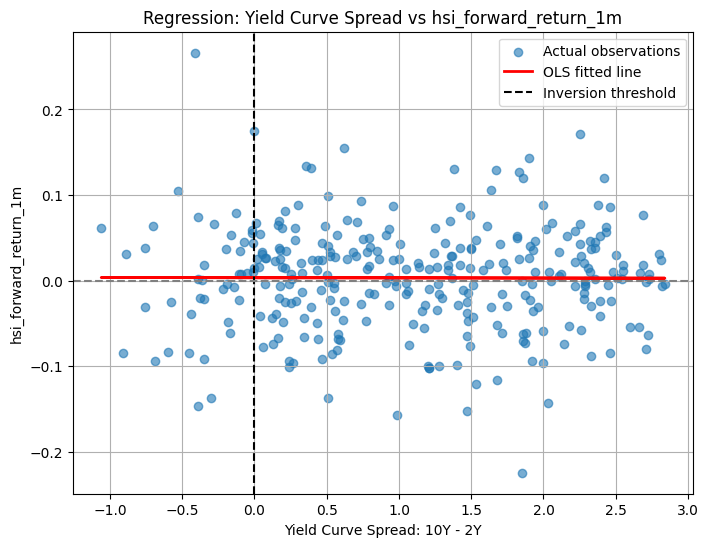

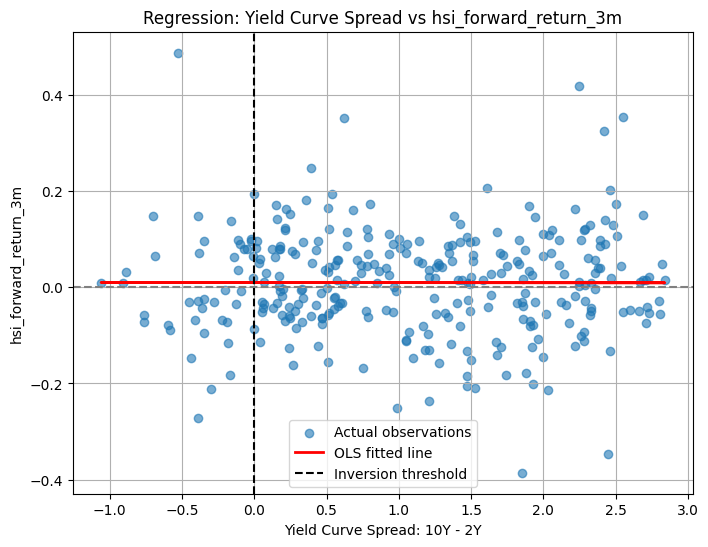

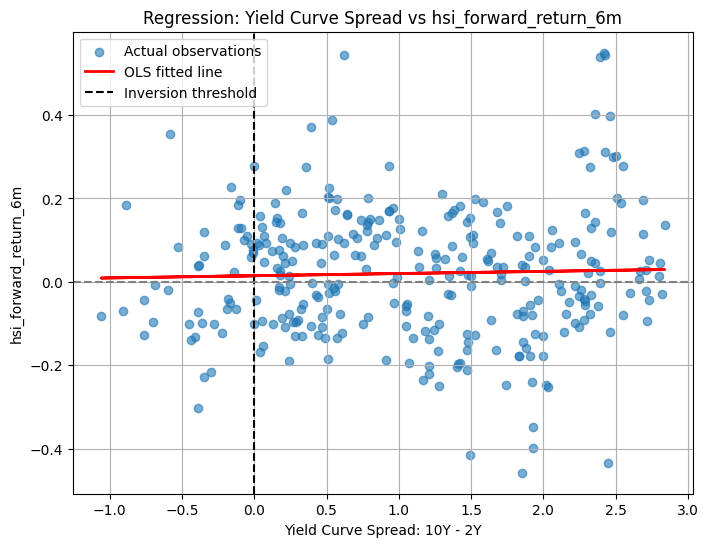

In [5]:

# ============================================================

# Part 2: Regression Analysis
# Question: Does the US yield curve spread relate to future HSI returns?

# ============================================================



import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Start from previous feature dataset
# -----------------------------

df = macro_feature_data.copy()

# -----------------------------
# 2. Define predictor and targets
# -----------------------------

# Predictor:
# This is the signal we are testing.
#
# yield_curve_slope = US 10Y yield - US 2Y yield.
# If beta is positive:
# higher yield spread predicts higher future HSI returns.
#
# If beta is negative:
# higher yield spread predicts lower future HSI returns.
predictor_col = "yield_curve_slope"

# Target variables:
# These are future HSI returns over different horizons.
target_cols = [
    "hsi_forward_return_1m",
    "hsi_forward_return_3m",
    "hsi_forward_return_6m"
]

# -----------------------------
# 3. Run regressions
# -----------------------------

regression_results = []

for target_col in target_cols:

    # Keep only rows where both predictor and target exist.
    reg_data = df[[predictor_col, target_col]].dropna()

    X = reg_data[[predictor_col]]
    Y = reg_data[target_col]

    # Add constant:
    # This creates the alpha/intercept term in the regression.
    #
    # Regression equation:
    # future_return = alpha + beta * yield_curve_slope
    X_with_constant = sm.add_constant(X)

    # OLS:
    # Ordinary Least Squares.
    # It fits the line that minimizes squared prediction errors.
    model = sm.OLS(Y, X_with_constant).fit()

    alpha = model.params["const"]
    beta = model.params[predictor_col]
    beta_pvalue = model.pvalues[predictor_col]
    r_squared = model.rsquared
    observations = int(model.nobs)

    regression_results.append({
        "target": target_col,
        "observations": observations,
        "alpha": alpha,
        "beta": beta,
        "beta_pvalue": beta_pvalue,
        "r_squared": r_squared
    })

    print("\n" + "=" * 80)
    print(f"REGRESSION RESULT: {target_col}")
    print("=" * 80)

    print(model.summary())

    print("\nKEY INTERPRETATION")
    print("-" * 50)

    print(f"Alpha: {alpha:.4%}")
    print(f"Beta: {beta:.4f}")
    print(f"Beta p-value: {beta_pvalue:.4f}")
    print(f"R-squared: {r_squared:.2%}")
    print(f"Observations: {observations}")

    if beta_pvalue < 0.05:
        print("Statistical read: beta is statistically significant at the 5% level.")

        if beta > 0:
            print("Reliable sample direction: higher yield curve spread predicts higher future HSI returns.")
        elif beta < 0:
            print("Reliable sample direction: higher yield curve spread predicts lower future HSI returns.")
        else:
            print("Reliable sample direction: beta is zero.")
    else:
        print("Statistical read: beta is NOT statistically significant at the 5% level.")

        if beta > 0:
            print("Sample direction: beta is positive, but not reliable enough to conclude predictive power.")
        elif beta < 0:
            print("Sample direction: beta is negative, but not reliable enough to conclude predictive power.")
        else:
            print("Sample direction: beta is zero.")

        print("Research conclusion: do not treat this regression as evidence of a reliable signal.")

# -----------------------------
# 4. Clean regression summary table
# -----------------------------

regression_table = pd.DataFrame(regression_results)

display_regression_table = regression_table.copy()

# Convert alpha and R-squared into nicer display percentages.
display_regression_table["alpha"] = display_regression_table["alpha"] * 100
display_regression_table["r_squared"] = display_regression_table["r_squared"] * 100

display_regression_table = display_regression_table.round({
    "alpha": 4,
    "beta": 4,
    "beta_pvalue": 4,
    "r_squared": 2
})

print("\n" + "=" * 80)
print("CLEAN REGRESSION SUMMARY TABLE")
print("=" * 80)
print(display_regression_table)

# -----------------------------
# 5. Plot fitted regression lines
# -----------------------------

for target_col in target_cols:

    reg_data = df[[predictor_col, target_col]].dropna()

    X = reg_data[predictor_col]
    Y = reg_data[target_col]

    X_with_constant = sm.add_constant(X)
    model = sm.OLS(Y, X_with_constant).fit()

    # Create fitted values from the regression line.
    fitted_values = model.predict(X_with_constant)

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X,
        Y,
        alpha=0.6,
        label="Actual observations"
    )

    plt.plot(
        X,
        fitted_values,
        color="red",
        linewidth=2,
        label="OLS fitted line"
    )

    plt.axvline(0, color="black", linestyle="--", label="Inversion threshold")
    plt.axhline(0, color="gray", linestyle="--")

    plt.title(f"Regression: Yield Curve Spread vs {target_col}")
    plt.xlabel("Yield Curve Spread: 10Y - 2Y")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True)
    plt.show()

The evidence does not support the hypothesis that the raw US yield curve spread predicts HSI forward returns. Using a simple linear regression, the relationship is tiny, statistically insignificant, and explains almost none of future HSI returns.

OUT-OF-SAMPLE SETUP
Train start: 2000-08-31 00:00:00
Train end: 2017-12-31 00:00:00
Train observations: 209

Test start: 2018-01-31 00:00:00
Test end: 2024-12-31 00:00:00
Test observations: 84

TRAINING REGRESSION SUMMARY
                              OLS Regression Results                             
Dep. Variable:     hsi_forward_return_1m   R-squared:                       0.002
Model:                               OLS   Adj. R-squared:                 -0.003
Method:                    Least Squares   F-statistic:                    0.3644
Date:                   Wed, 22 Jul 2026   Prob (F-statistic):              0.547
Time:                           13:48:57   Log-Likelihood:                 292.40
No. Observations:                    209   AIC:                            -580.8
Df Residuals:                        207   BIC:                            -574.1
Df Model:                              1                                         
Covariance Type:               nonrobust

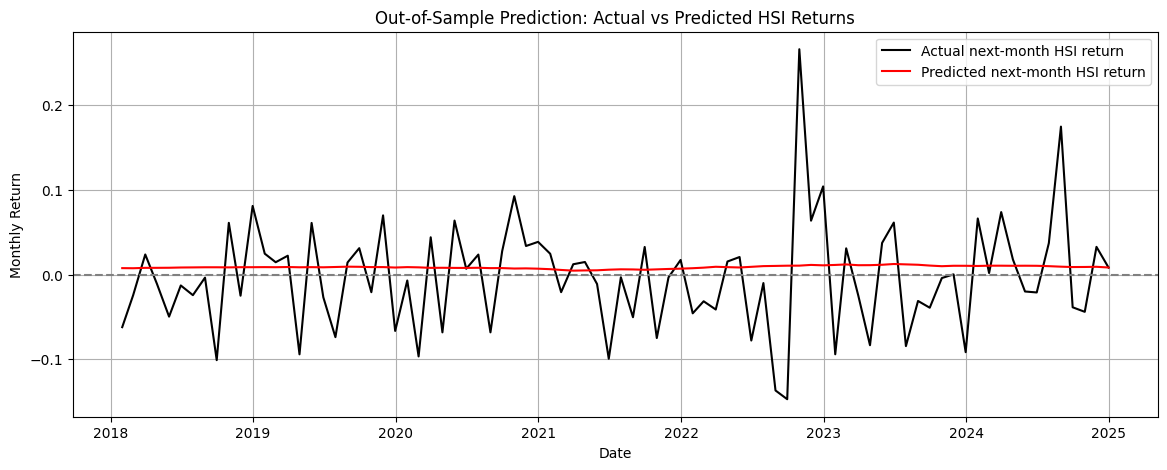

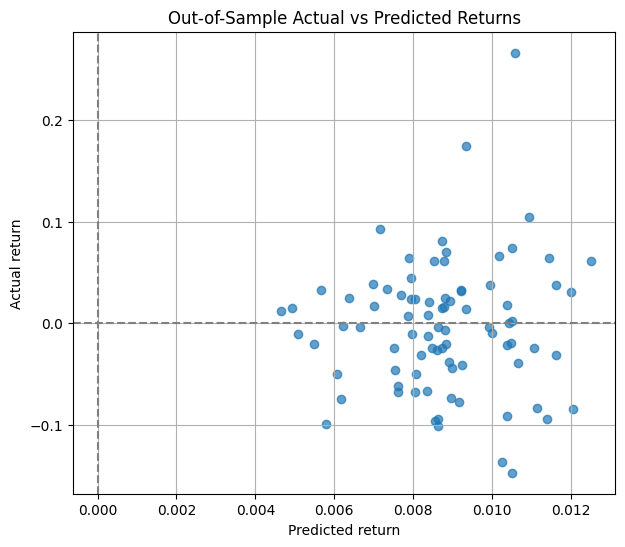

In [6]:
# ============================================================

# Part 3: Out-of-Sample Test
# Train: before 2018
# Test: 2018-2024

# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Start from previous feature dataset
# -----------------------------

df = macro_feature_data.copy()

# -----------------------------
# 2. Choose predictor and target
# -----------------------------

# Predictor:
# We start with the simple yield curve slope.
predictor_col = "yield_curve_slope"

# Target:
# Start with next-month HSI return.
# Later we can repeat for 3m and 6m.
target_col = "hsi_forward_return_1m"

model_data = df[[predictor_col, target_col]].dropna()

# -----------------------------
# 3. Split train and test periods
# -----------------------------

# Train period:
# The model learns only from data before 2018.
train = model_data[model_data.index < "2018-01-01"]

# Test period:
# The model is evaluated on unseen data from 2018 to 2024.
test = model_data[
    (model_data.index >= "2018-01-01") &
    (model_data.index <= "2024-12-31")
]

print("OUT-OF-SAMPLE SETUP")
print("=" * 50)
print("Train start:", train.index.min())
print("Train end:", train.index.max())
print("Train observations:", len(train))

print("\nTest start:", test.index.min())
print("Test end:", test.index.max())
print("Test observations:", len(test))

# -----------------------------
# 4. Fit model on train data only
# -----------------------------

X_train = train[[predictor_col]]
Y_train = train[target_col]

X_train_const = sm.add_constant(X_train)

# OLS regression:
# The model learns alpha and beta using only old data.
model = sm.OLS(Y_train, X_train_const).fit()

print("\nTRAINING REGRESSION SUMMARY")
print("=" * 50)
print(model.summary())

# -----------------------------
# 5. Predict on test data
# -----------------------------

X_test = test[[predictor_col]]
Y_test = test[target_col]

X_test_const = sm.add_constant(X_test)

# Prediction:
# Use the alpha and beta learned from training data
# to predict future HSI returns in the test period.
test_predictions = model.predict(X_test_const)

# -----------------------------
# 6. Out-of-sample performance metrics
# -----------------------------

# Out-of-sample R-squared:
# Measures how much of the test-period variation is explained by the model.
#
# If positive: model beats simply predicting the average.
# If near zero: model adds little.
# If negative: model is worse than a naive average forecast.
oos_r2 = r2_score(Y_test, test_predictions)

# RMSE:
# Root Mean Squared Error.
# Average prediction error size, in return units.
rmse = np.sqrt(mean_squared_error(Y_test, test_predictions))

# Directional accuracy:
# Measures how often the model predicted the correct sign of return.
# Example:
# predicted positive and actual positive = correct.
directional_accuracy = np.mean(
    np.sign(test_predictions) == np.sign(Y_test)
)

print("\nOUT-OF-SAMPLE RESULTS")
print("=" * 50)
print(f"Out-of-sample R-squared: {oos_r2:.2%}")
print(f"RMSE: {rmse:.2%}")
print(f"Directional accuracy: {directional_accuracy:.2%}")

# -----------------------------
# 7. Plot actual vs predicted returns
# -----------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    Y_test.index,
    Y_test,
    label="Actual next-month HSI return",
    color="black"
)

plt.plot(
    Y_test.index,
    test_predictions,
    label="Predicted next-month HSI return",
    color="red"
)

plt.axhline(0, color="gray", linestyle="--")

plt.title("Out-of-Sample Prediction: Actual vs Predicted HSI Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 8. Plot prediction scatter
# -----------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    test_predictions,
    Y_test,
    alpha=0.7
)

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

plt.title("Out-of-Sample Actual vs Predicted Returns")
plt.xlabel("Predicted return")
plt.ylabel("Actual return")
plt.grid(True)
plt.show()

The raw US yield curve slope does not provide reliable out-of-sample predictive power for next-month HSI returns over 2018-2024.

#**Signal Construction & Backtesting**

BACKTEST RESULTS
                         Strategy  Total Return  Annualized Return  \
0                Buy and Hold HSI         45.59               1.46   
1  Yield Curve Signal Before Cost         16.46               0.59   
2   Yield Curve Signal After Cost         14.98               0.54   

   Annualized Volatility  Sharpe Ratio  Max Drawdown  Calmar Ratio  
0                  21.13          0.07        -59.14          0.02  
1                  18.77          0.03        -59.14          0.01  
2                  18.77          0.03        -59.14          0.01  

Signal counts:
signal
1    268
0     43
Name: count, dtype: int64

Number of trades:
13


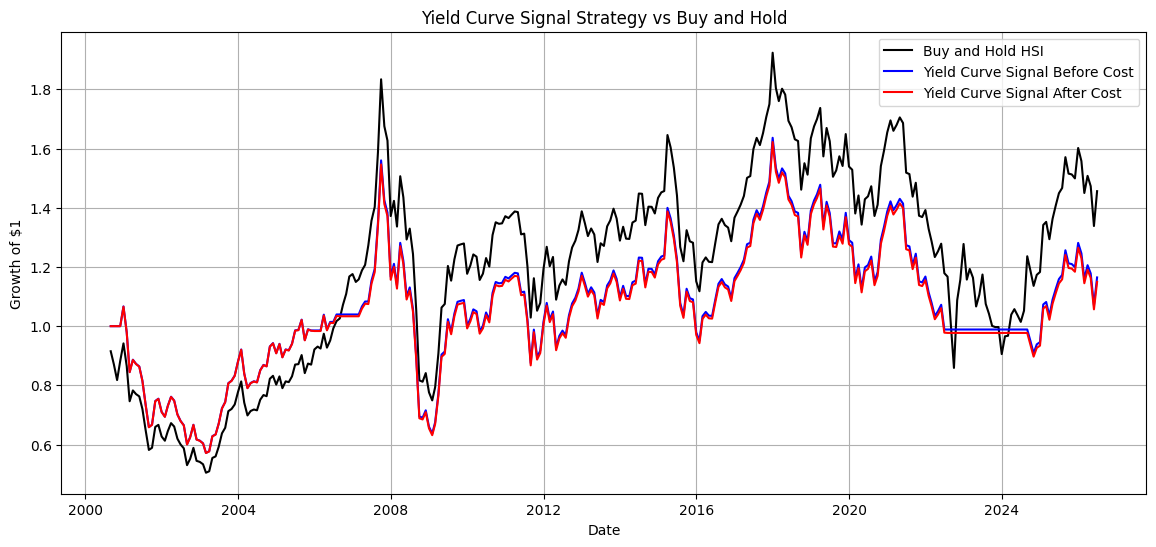

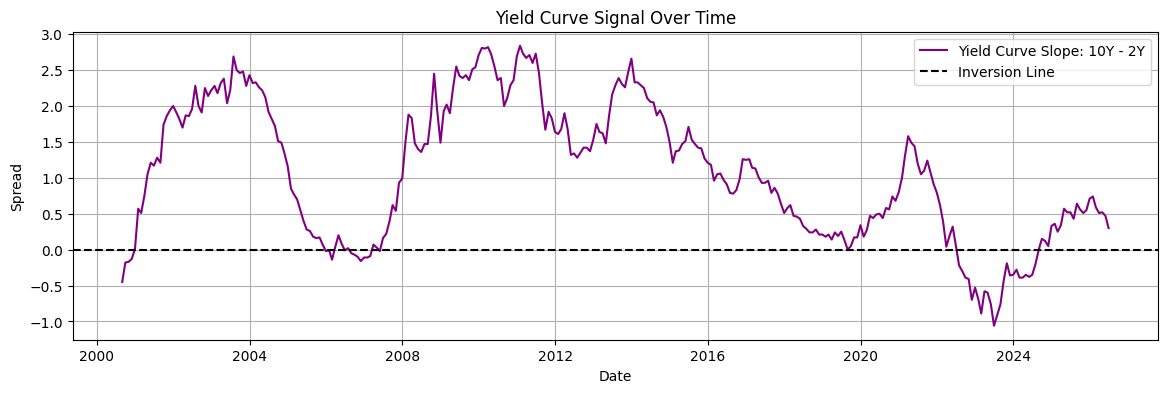

In [7]:
# Goal:
# Turn the yield curve hypothesis into a trading rule and test it.
#
# Hypothesis:
# If the US yield curve is normal, global risk conditions may be healthier,
# so we go long HSI.
#
# If the US yield curve is inverted, recession / tightening risk may be higher,
# so we avoid HSI and stay in cash.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Start from feature dataset
# -----------------------------

df = macro_feature_data.copy()

# -----------------------------
# 2. Define the trading signal
# -----------------------------

# yield_curve_slope = US 10Y yield - US 2Y yield
#
# If slope > 0:
# Normal yield curve.
# Signal = 1, meaning long HSI.
#
# If slope < 0:
# Inverted yield curve.
# Signal = 0, meaning stay in cash.
df["signal"] = np.where(df["yield_curve_slope"] > 0, 1, 0)

# -----------------------------
# 3. Avoid look-ahead bias
# -----------------------------

# Look-ahead bias means using information that would not have been known
# at the time of the trade.
#


# It represents next month's HSI return.
df["strategy_return_before_cost"] = (
    df["signal"] * df["hsi_forward_return_1m"]
)

# Buy-and-hold benchmark:
# Always invested in HSI.
df["buy_hold_return"] = df["hsi_forward_return_1m"]

# -----------------------------
# 4. Add transaction costs
# -----------------------------

# Transaction cost assumption:
# 10 basis points = 0.10% = 0.001
#
# We subtract cost whenever the signal changes.
# Example:
# signal goes from 0 to 1 = buy trade
# signal goes from 1 to 0 = sell trade
transaction_cost = 0.001

# trade = 1 when position changes, 0 otherwise.
df["trade"] = df["signal"].diff().abs()

# First row may become NaN because there is no previous signal.
df["trade"] = df["trade"].fillna(0)

# Strategy return after cost:
df["strategy_return_after_cost"] = (
    df["strategy_return_before_cost"] -
    df["trade"] * transaction_cost
)

# -----------------------------
# 5. Clean backtest dataframe
# -----------------------------

backtest = df[
    [
        "yield_curve_slope",
        "signal",
        "trade",
        "hsi_forward_return_1m",
        "strategy_return_before_cost",
        "strategy_return_after_cost",
        "buy_hold_return"
    ]
].dropna().copy()

# -----------------------------
# 6. Performance metric function
# -----------------------------

def calculate_performance(returns, name):
    """
    returns:
    Monthly strategy returns.

    total_return:
    Total compounded return over the full backtest.

    annualized_return:
    Average yearly return, converted from monthly returns.

    annualized_volatility:
    Yearly risk level, converted from monthly volatility.

    Sharpe ratio:
    Return per unit of risk.
    Higher is better.
    We assume risk-free rate = 0 for simplicity.

    max_drawdown:
    Worst peak-to-trough loss.
    Example:
    Portfolio rises to 100, falls to 70.
    Max drawdown = -30%.

    Calmar ratio:
    Annualized return divided by absolute max drawdown.
    It asks: how much return did we earn relative to the worst pain?
    """

    returns = returns.dropna()

    equity_curve = (1 + returns).cumprod()

    total_return = equity_curve.iloc[-1] - 1

    years = len(returns) / 12

    annualized_return = (1 + total_return) ** (1 / years) - 1

    annualized_volatility = returns.std() * np.sqrt(12)

    sharpe_ratio = annualized_return / annualized_volatility

    running_peak = equity_curve.cummax()
    drawdown = equity_curve / running_peak - 1
    max_drawdown = drawdown.min()

    calmar_ratio = annualized_return / abs(max_drawdown)

    return {
        "Strategy": name,
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
        "Calmar Ratio": calmar_ratio
    }

# -----------------------------
# 7. Compare strategy vs benchmark
# -----------------------------

results = []

results.append(
    calculate_performance(
        backtest["buy_hold_return"],
        "Buy and Hold HSI"
    )
)

results.append(
    calculate_performance(
        backtest["strategy_return_before_cost"],
        "Yield Curve Signal Before Cost"
    )
)

results.append(
    calculate_performance(
        backtest["strategy_return_after_cost"],
        "Yield Curve Signal After Cost"
    )
)

performance_table = pd.DataFrame(results)

# Make percentage columns easier to read.
display_table = performance_table.copy()

percentage_cols = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown"
]

for col in percentage_cols:
    display_table[col] = display_table[col] * 100

display_table = display_table.round({
    "Total Return": 2,
    "Annualized Return": 2,
    "Annualized Volatility": 2,
    "Sharpe Ratio": 2,
    "Max Drawdown": 2,
    "Calmar Ratio": 2
})

print("BACKTEST RESULTS")
print("=" * 70)
print(display_table)

print("\nSignal counts:")
print(backtest["signal"].value_counts())

print("\nNumber of trades:")
print(int(backtest["trade"].sum()))

# -----------------------------
# 8. Plot equity curves
# -----------------------------

backtest["buy_hold_equity"] = (
    1 + backtest["buy_hold_return"]
).cumprod()

backtest["strategy_equity_before_cost"] = (
    1 + backtest["strategy_return_before_cost"]
).cumprod()

backtest["strategy_equity_after_cost"] = (
    1 + backtest["strategy_return_after_cost"]
).cumprod()

plt.figure(figsize=(14, 6))

plt.plot(
    backtest.index,
    backtest["buy_hold_equity"],
    label="Buy and Hold HSI",
    color="black"
)

plt.plot(
    backtest.index,
    backtest["strategy_equity_before_cost"],
    label="Yield Curve Signal Before Cost",
    color="blue"
)

plt.plot(
    backtest.index,
    backtest["strategy_equity_after_cost"],
    label="Yield Curve Signal After Cost",
    color="red"
)

plt.title("Yield Curve Signal Strategy vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 9. Plot signal over time
# -----------------------------

plt.figure(figsize=(14, 4))

plt.plot(
    backtest.index,
    backtest["yield_curve_slope"],
    label="Yield Curve Slope: 10Y - 2Y",
    color="purple"
)

plt.axhline(0, color="black", linestyle="--", label="Inversion Line")

plt.title("Yield Curve Signal Over Time")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)

The simple yield-curve inversion trading rule did not improve HSI performance relative to buy-and-hold. Although it slightly reduced volatility, it also reduced returns and failed to reduce the maximum drawdown. After transaction costs, the strategy produced a lower Sharpe ratio and weaker Calmar ratio than the benchmark.

#**Risk Analysis**

25 BACKTEST FOUND
--------------------------------------------------
Backtest columns:
['yield_curve_slope', 'signal', 'trade', 'hsi_forward_return_1m', 'strategy_return_before_cost', 'strategy_return_after_cost', 'buy_hold_return', 'buy_hold_equity', 'strategy_equity_before_cost', 'strategy_equity_after_cost']

RISK DATASET READY
--------------------------------------------------
Rows: 311
Start date: 2000-08-31 00:00:00
End date: 2026-06-30 00:00:00

Risk dataframe columns:
['spread', 'hsi_return', 'strategy_return', 'signal', 'trade']

Latest rows:
            spread  hsi_return  strategy_return  signal  trade
2026-02-28    0.59   -0.069184        -0.069184       1    0.0
2026-03-31    0.51    0.039873         0.039873       1    0.0
2026-04-30    0.52   -0.023050        -0.023050       1    0.0
2026-05-31    0.47   -0.091388        -0.091388       1    0.0
2026-06-30    0.30    0.087917         0.087917       1    0.0

DRAWDOWN ANALYSIS
---------------------------------------------

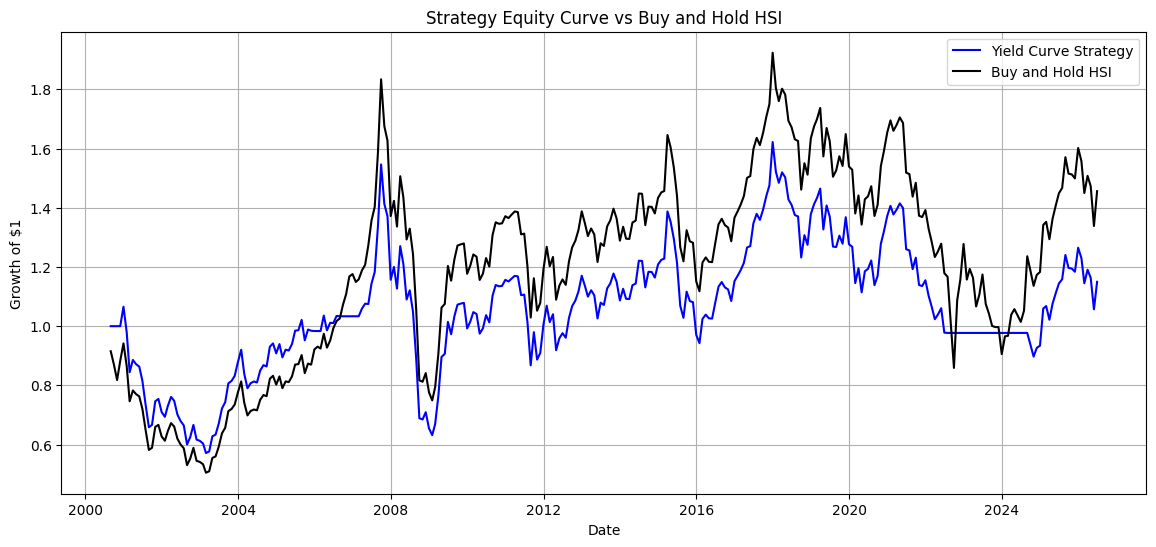

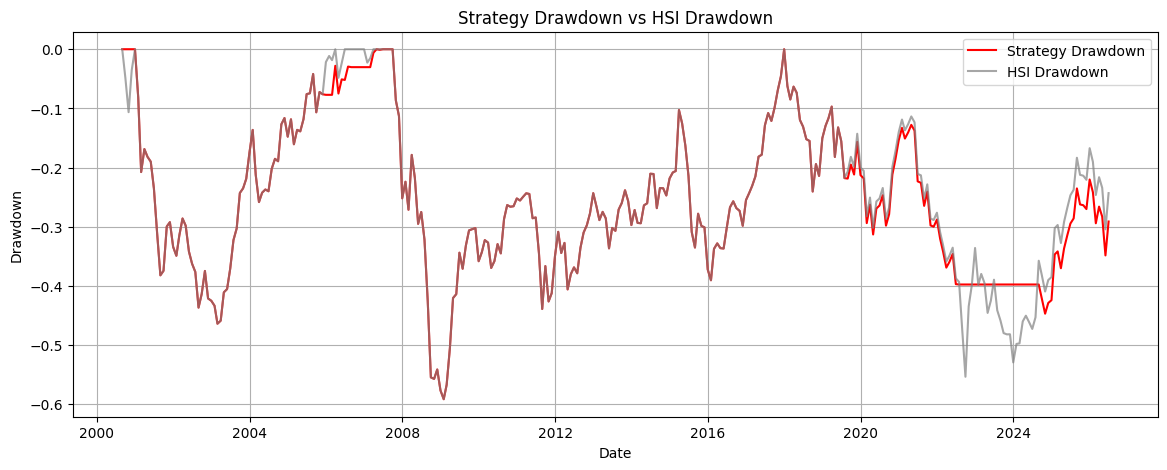

In [8]:

# Goal:
# Understand when and why the yield-curve strategy fails.
#

#
# Your previous column names:
# yield_curve_slope              = US 10Y yield - US 2Y yield
# hsi_forward_return_1m          = next month's HSI return
# strategy_return_after_cost     = strategy return after transaction costs
# signal                         = trading position
# trade                          = whether the strategy traded that month

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Check backtest exists
# -----------------------------

if "backtest" not in globals():
    raise NameError("backtest is not defined. Run your previous code first.")

print("25 BACKTEST FOUND")
print("-" * 50)

print("Backtest columns:")
print(backtest.columns.tolist())

# -----------------------------
# 2. Create risk dataframe
# -----------------------------

risk_df = backtest[
    [
        "yield_curve_slope",
        "hsi_forward_return_1m",
        "strategy_return_after_cost",
        "signal",
        "trade"
    ]
].copy()


risk_df = risk_df.rename(columns={
    "yield_curve_slope": "spread",
    "hsi_forward_return_1m": "hsi_return",
    "strategy_return_after_cost": "strategy_return"
})

risk_df = risk_df.dropna()
risk_df = risk_df.sort_index()

if risk_df.empty:
    raise ValueError("risk_df is empty after dropna(). Check data.")

print("\nRISK DATASET READY")
print("-" * 50)

print("Rows:", len(risk_df))
print("Start date:", risk_df.index.min())
print("End date:", risk_df.index.max())

print("\nRisk dataframe columns:")
print(risk_df.columns.tolist())

print("\nLatest rows:")
print(risk_df.tail())

# -----------------------------
# 3. Build equity curves
# -----------------------------

# Equity curve:
# Shows how $1 grows over time.
#
# Example:
# If return is +5%, equity goes from 1.00 to 1.05.
# If next return is -2%, equity goes from 1.05 to 1.05 * 0.98.
risk_df["strategy_equity"] = (1 + risk_df["strategy_return"]).cumprod()
risk_df["hsi_equity"] = (1 + risk_df["hsi_return"]).cumprod()

# -----------------------------
# 4. Drawdown analysis
# -----------------------------

# Running peak:
# Highest equity value reached up to each date.
risk_df["strategy_peak"] = risk_df["strategy_equity"].cummax()
risk_df["hsi_peak"] = risk_df["hsi_equity"].cummax()

# Drawdown:
# Current fall from the previous high.
#
# Example:
# If equity peaked at 1.50 and is now 1.20:
# drawdown = 1.20 / 1.50 - 1 = -20%.
risk_df["strategy_drawdown"] = (
    risk_df["strategy_equity"] / risk_df["strategy_peak"] - 1
)

risk_df["hsi_drawdown"] = (
    risk_df["hsi_equity"] / risk_df["hsi_peak"] - 1
)

worst_strategy_drawdown = risk_df["strategy_drawdown"].min()
worst_strategy_drawdown_date = risk_df["strategy_drawdown"].idxmin()

worst_hsi_drawdown = risk_df["hsi_drawdown"].min()
worst_hsi_drawdown_date = risk_df["hsi_drawdown"].idxmin()

print("\nDRAWDOWN ANALYSIS")
print("-" * 50)

print("Worst strategy drawdown:", f"{worst_strategy_drawdown:.2%}")
print("Worst strategy drawdown date:", worst_strategy_drawdown_date)

print("Worst HSI drawdown:", f"{worst_hsi_drawdown:.2%}")
print("Worst HSI drawdown date:", worst_hsi_drawdown_date)

# -----------------------------
# 5. Curve regime analysis
# -----------------------------

# Curve regime:
# Normal Curve = spread > 0, meaning 10Y yield is above 2Y yield.
# Inverted Curve = spread < 0, meaning 2Y yield is above 10Y yield.
#
# We test whether the strategy behaves differently in these two regimes.
risk_df["curve_regime"] = np.where(
    risk_df["spread"] < 0,
    "Inverted Curve",
    "Normal Curve"
)

regime_stats = risk_df.groupby("curve_regime")["strategy_return"].agg(
    mean_monthly_return="mean",
    monthly_volatility="std",
    observations="count"
)

# Annualized return:
# Converts average monthly return into yearly return.
regime_stats["annualized_return"] = (
    (1 + regime_stats["mean_monthly_return"]) ** 12 - 1
)

# Annualized volatility:
# Converts monthly volatility into yearly volatility.
regime_stats["annualized_volatility"] = (
    regime_stats["monthly_volatility"] * np.sqrt(12)
)

# Sharpe ratio:
# Return per unit of risk.
# Higher is better.
regime_stats["sharpe_ratio"] = (
    regime_stats["annualized_return"] / regime_stats["annualized_volatility"]
)

regime_display = regime_stats.copy()

percentage_columns = [
    "mean_monthly_return",
    "monthly_volatility",
    "annualized_return",
    "annualized_volatility"
]

for col in percentage_columns:
    regime_display[col] = regime_display[col] * 100

regime_display = regime_display.round({
    "mean_monthly_return": 2,
    "monthly_volatility": 2,
    "observations": 0,
    "annualized_return": 2,
    "annualized_volatility": 2,
    "sharpe_ratio": 2
})

print("\nSTRATEGY PERFORMANCE BY CURVE REGIME")
print("-" * 50)
print(regime_display)

# -----------------------------
# 6. Correlation with HSI
# -----------------------------

# If correlation is very high, the strategy may just be hidden HSI exposure.
# If correlation is lower, the strategy may be adding timing/diversification value.
strategy_hsi_corr = risk_df["strategy_return"].corr(risk_df["hsi_return"])

print("\nCORRELATION CHECK")
print("-" * 50)
print("Strategy-HSI return correlation:", round(strategy_hsi_corr, 3))

# -----------------------------
# 7. Stress testing
# -----------------------------

# Stress testing:
# We check how the strategy behaved during known difficult macro periods.
stress_periods = {
    "COVID Crash": ("2020-01-01", "2020-06-30"),
    "China Crackdown": ("2021-02-01", "2021-12-31"),
    "Fed Hike Cycle": ("2022-01-01", "2022-12-31")
}

stress_results = []

for name, (start, end) in stress_periods.items():
    period = risk_df.loc[start:end].copy()

    if len(period) == 0:
        continue

    strategy_total_return = (1 + period["strategy_return"]).prod() - 1
    hsi_total_return = (1 + period["hsi_return"]).prod() - 1

    period_strategy_equity = (1 + period["strategy_return"]).cumprod()
    period_strategy_peak = period_strategy_equity.cummax()
    period_strategy_drawdown = period_strategy_equity / period_strategy_peak - 1

    strategy_max_drawdown = period_strategy_drawdown.min()

    stress_results.append({
        "Period": name,
        "Start": start,
        "End": end,
        "Strategy Total Return": strategy_total_return,
        "HSI Total Return": hsi_total_return,
        "Strategy Max Drawdown": strategy_max_drawdown,
        "Observations": len(period)
    })

stress_results = pd.DataFrame(stress_results)

if not stress_results.empty:
    stress_display = stress_results.copy()

    stress_percentage_cols = [
        "Strategy Total Return",
        "HSI Total Return",
        "Strategy Max Drawdown"
    ]

    for col in stress_percentage_cols:
        stress_display[col] = stress_display[col] * 100

    stress_display = stress_display.round({
        "Strategy Total Return": 2,
        "HSI Total Return": 2,
        "Strategy Max Drawdown": 2
    })

    print("\nSTRESS TEST RESULTS")
    print("-" * 50)
    print(stress_display)
else:
    print("\nNo stress-period data found.")

# -----------------------------
# 8. Position sizing by signal strength
# -----------------------------

# Signal strength:
# We use the absolute yield curve spread.
#
# Bigger absolute spread = stronger macro signal.
# Very positive spread = strongly normal curve.
# Very negative spread = strongly inverted curve.
risk_df["signal_strength"] = risk_df["spread"].abs()

# Position size:
# Scale signal strength by the strongest signal seen in the past 60 months.
#
# If current signal strength is near the 60-month max, position size is near 1.
# If current signal strength is weak, position size is smaller.
risk_df["position_size"] = (
    risk_df["signal_strength"] /
    risk_df["signal_strength"].rolling(60).max()
)

# Cap exposure at 100%.
risk_df["position_size"] = risk_df["position_size"].clip(0, 1)

# Sized strategy:
# Same direction as signal, but position size changes with signal strength.
#
# We shift position_size by 1 period to avoid look-ahead bias.
risk_df["sized_strategy_return"] = (
    risk_df["signal"] *
    risk_df["position_size"].shift(1) *
    risk_df["hsi_return"]
)

print("\nPOSITION SIZING CHECK")
print("-" * 50)
print(risk_df[
    [
        "spread",
        "signal",
        "signal_strength",
        "position_size",
        "sized_strategy_return"
    ]
].tail())

# -----------------------------
# 9. Plot equity curves
# -----------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    risk_df.index,
    risk_df["strategy_equity"],
    label="Yield Curve Strategy",
    color="blue"
)

plt.plot(
    risk_df.index,
    risk_df["hsi_equity"],
    label="Buy and Hold HSI",
    color="black"
)

plt.title("Strategy Equity Curve vs Buy and Hold HSI")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 10. Plot drawdowns
# -----------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    risk_df.index,
    risk_df["strategy_drawdown"],
    label="Strategy Drawdown",
    color="red"
)

plt.plot(
    risk_df.index,
    risk_df["hsi_drawdown"],
    label="HSI Drawdown",
    color="gray",
    alpha=0.7
)

plt.title("Strategy Drawdown vs HSI Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

- The yield-curve rule did not protect the portfolio from the biggest HSI drawdown.

- Being long HSI during normal yield curve periods earned positive returns, but not enough to look like a strong standalone strategy.

- The strategy is not very independent.
It is mostly long HSI most of the time.

- The signal did not protect well during major macro stress periods.
During 2022, it made things worse.

- The curve was normal, so signal = long.
But the signal strength was not huge, so the model only allocated about 24%.

The US yield curve alone does not appear to be a strong standalone timing signal for HSI.
The strategy remains highly correlated with HSI, fails to reduce the worst drawdown, and does not protect well during key stress periods.
Its main weakness is that it is long HSI during many bad equity regimes.

#**Alternative Signals**

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1075/2587155827.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hsi_monthly = hsi.resample("M").last().to_frame()
/tmp/ipykernel_1075/2587155827.py:108: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  credit_monthly = credit_spread.resample("M").last()
/tmp/ipykernel_1075/2587155827.py:109: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vix_monthly = vix.resample("M").last()
/tmp/ipykernel_1075/2587155827.py:110: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fed_monthly = fed_funds.resample("M").last()


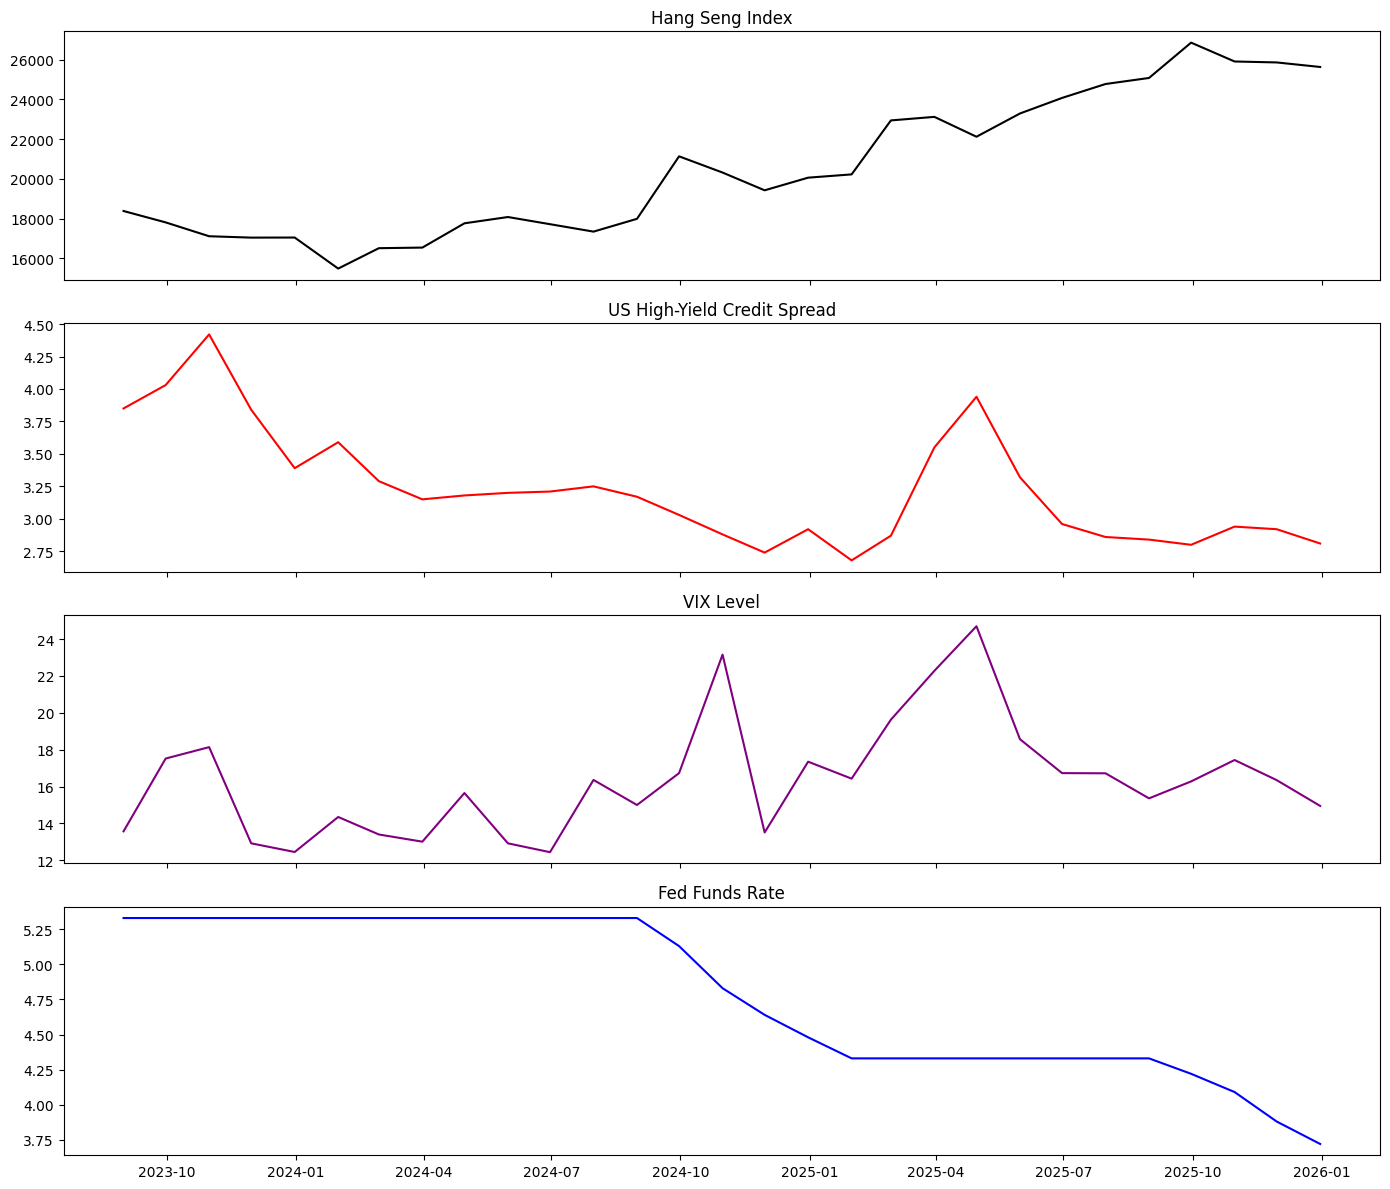

ALTERNATIVE MACRO SIGNAL TEST RESULTS
------------------------------------------------------------
                  signal              target    beta  p_value  r_squared  \
0    credit_spread_level  HSI_return_next_1m -0.0288   0.2362       5.16   
1    credit_spread_level  HSI_return_next_3m -0.0541   0.1212       8.66   
2    credit_spread_level  HSI_return_next_6m -0.0374   0.4063       2.57   
3   credit_spread_change  HSI_return_next_1m -0.0160   0.6782       0.65   
4   credit_spread_change  HSI_return_next_3m  0.0008   0.9888       0.00   
5   credit_spread_change  HSI_return_next_6m  0.0064   0.9279       0.03   
6              vix_level  HSI_return_next_1m -0.0012   0.7192       0.49   
7              vix_level  HSI_return_next_3m -0.0008   0.8733       0.10   
8              vix_level  HSI_return_next_6m  0.0023   0.7153       0.50   
9             vix_change  HSI_return_next_1m -0.0040   0.2190       5.54   
10            vix_change  HSI_return_next_3m -0.0037   0.4353    

In [9]:

# ============================================================

# Question 1:
# Do alternative US macro risk signals predict future Hang Seng returns?
#
# Signals tested:
# 1. Credit spreads
# 2. VIX level
# 3. Fed funds rate change

# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------
# 1. Helper function to download FRED data
# -----------------------------

def load_fred_series(series_id, start="2010-01-01"):
    """
    FRED = Federal Reserve Economic Data.

    This function downloads one FRED time series using its series ID.

    Example:
    VIXCLS = VIX index
    FEDFUNDS = effective federal funds rate
    BAMLH0A0HYM2 = US high-yield credit spread
    """

    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    data = pd.read_csv(url)

    data.columns = ["date", series_id]

    data["date"] = pd.to_datetime(data["date"])

    data = data.set_index("date")

    # FRED sometimes uses "." for missing values.
    data[series_id] = pd.to_numeric(data[series_id], errors="coerce")

    data = data.loc[start:]

    return data


# -----------------------------
# 2. Load HSI data
# -----------------------------

hsi = yf.download(
    "^HSI",
    start="2010-01-01",
    auto_adjust=True
)["Close"]

# Sometimes yfinance returns a DataFrame instead of a Series.
# This keeps only one clean price column.
if isinstance(hsi, pd.DataFrame):
    hsi = hsi.iloc[:, 0]

hsi = hsi.dropna()
hsi.name = "HSI_price"

# Convert daily HSI price to monthly price.
# "M" means month-end.
hsi_monthly = hsi.resample("M").last().to_frame()

# Monthly HSI return:
# Percentage change from previous month-end to current month-end.
hsi_monthly["HSI_return"] = hsi_monthly["HSI_price"].pct_change()


# -----------------------------
# 3. Load alternative macro signals from FRED
# -----------------------------

# Credit spread:
# This is the extra yield investors demand to hold risky corporate bonds
# instead of safer government bonds.
#
# Higher credit spread = more fear / tighter financial conditions.
credit_spread = load_fred_series("BAMLH0A0HYM2")

# VIX:
# Market's expectation of S&P 500 volatility.
# Higher VIX = more fear / uncertainty.
vix = load_fred_series("VIXCLS")

# Fed funds rate:
# Main short-term US policy interest rate.
# Rising Fed funds = tighter monetary policy.
fed_funds = load_fred_series("FEDFUNDS")


# -----------------------------
# 4. Convert all macro data to monthly frequency
# -----------------------------

# For monthly modelling, everything must be on the same frequency.
# We use month-end values.
credit_monthly = credit_spread.resample("M").last()
vix_monthly = vix.resample("M").last()
fed_monthly = fed_funds.resample("M").last()


# -----------------------------
# 5. Combine into one clean dataframe
# -----------------------------

df = pd.concat(
    [
        hsi_monthly,
        credit_monthly,
        vix_monthly,
        fed_monthly
    ],
    axis=1
)

df = df.rename(columns={
    "BAMLH0A0HYM2": "credit_spread",
    "VIXCLS": "vix",
    "FEDFUNDS": "fed_funds"
})

# Drop rows where important data is missing.
df = df.dropna()

# -----------------------------
# 6. Feature engineering
# -----------------------------

# Credit spread level:
# High value = risky credit markets are stressed.
df["credit_spread_level"] = df["credit_spread"]

# Credit spread change:
# Positive change = credit stress is increasing.
df["credit_spread_change"] = df["credit_spread"].diff()

# VIX level:
# High value = equity market fear is high.
df["vix_level"] = df["vix"]

# VIX change:
# Positive change = fear is increasing.
df["vix_change"] = df["vix"].diff()

# Fed funds rate level:
# Higher value = tighter monetary policy.
df["fed_funds_level"] = df["fed_funds"]

# Fed funds rate change:
# Positive value = Fed is tightening policy.
df["fed_funds_change"] = df["fed_funds"].diff()

# Forward HSI returns:
# These are the returns we are trying to predict.
#
# shift(-1) means next month's return.
# shift(-3) means return 3 months ahead.
# shift(-6) means return 6 months ahead.
df["HSI_return_next_1m"] = df["HSI_return"].shift(-1)
df["HSI_return_next_3m"] = df["HSI_price"].shift(-3) / df["HSI_price"] - 1
df["HSI_return_next_6m"] = df["HSI_price"].shift(-6) / df["HSI_price"] - 1

df = df.dropna()


# -----------------------------
# 7. Quick exploratory plots
# -----------------------------

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df["HSI_price"], color="black")
axes[0].set_title("Hang Seng Index")

axes[1].plot(df.index, df["credit_spread_level"], color="red")
axes[1].set_title("US High-Yield Credit Spread")

axes[2].plot(df.index, df["vix_level"], color="purple")
axes[2].set_title("VIX Level")

axes[3].plot(df.index, df["fed_funds_level"], color="blue")
axes[3].set_title("Fed Funds Rate")

plt.tight_layout()
plt.show()


# -----------------------------
# 8. Regression testing function
# -----------------------------

def run_predictive_regression(data, signal_col, target_col):
    """
    Predictive regression:

    Future HSI return = alpha + beta * macro signal

    alpha:
    Average future HSI return when the signal is zero.

    beta:
    How much future HSI return changes when the signal increases by 1 unit.

    p-value:
    Tests whether beta is statistically different from zero.
    If p-value < 0.05, we call it statistically significant at the 5% level.

    R-squared:
    Percentage of future HSI return variation explained by the signal.
    """

    temp = data[[signal_col, target_col]].dropna()

    X = temp[signal_col]
    Y = temp[target_col]

    # Add constant term for alpha.
    X = sm.add_constant(X)

    model = sm.OLS(Y, X).fit()

    beta = model.params[signal_col]
    p_value = model.pvalues[signal_col]
    r_squared = model.rsquared

    return {
        "signal": signal_col,
        "target": target_col,
        "beta": beta,
        "p_value": p_value,
        "r_squared": r_squared,
        "significant_5pct": p_value < 0.05
    }


# -----------------------------
# 9. Test all alternative signals
# -----------------------------

signals = [
    "credit_spread_level",
    "credit_spread_change",
    "vix_level",
    "vix_change",
    "fed_funds_level",
    "fed_funds_change"
]

targets = [
    "HSI_return_next_1m",
    "HSI_return_next_3m",
    "HSI_return_next_6m"
]

results = []

for signal in signals:
    for target in targets:
        result = run_predictive_regression(df, signal, target)
        results.append(result)

results_df = pd.DataFrame(results)

# Format results for readability.
display_results = results_df.copy()
display_results["beta"] = display_results["beta"].round(4)
display_results["p_value"] = display_results["p_value"].round(4)
display_results["r_squared"] = (display_results["r_squared"] * 100).round(2)

print("ALTERNATIVE MACRO SIGNAL TEST RESULTS")
print("-" * 60)
print(display_results)


# -----------------------------
# 10. Basic interpretation helper
# -----------------------------

print("\nSIGNIFICANT SIGNALS AT 5% LEVEL")
print("-" * 60)

significant = display_results[display_results["significant_5pct"] == True]

if significant.empty:
    print("No alternative signal is statistically significant at the 5% level.")
else:
    print(significant)

We tested credit spreads, VIX, and Fed funds changes as alternative macro predictors. None were statistically significant at the 5% level across 1m, 3m, and 6m horizons. Credit spread level showed the most economically plausible negative relationship, especially at the 3-month horizon, but the evidence was not strong enough to treat it as a robust standalone signal.

In [10]:
# ============================================================
#
# Q2: Do alternative US macro signals predict other Asian Markets?
#
# Markets:
# 1. Hang Seng Index (HSI)
# 2. Nikkei 225
# 3. KOSPI
#
# Macro signals:
# 1. US high-yield credit spread
# 2. VIX level
# 3. Fed funds rate
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm

# -----------------------------
# 1. Helper function to download FRED data
# -----------------------------

def load_fred_series(series_id, start="2010-01-01"):
    """
    Downloads one macro time series from FRED.

    FRED = Federal Reserve Economic Data.

    series_id examples:
    BAMLH0A0HYM2 = US high-yield credit spread
    VIXCLS = VIX index
    FEDFUNDS = effective federal funds rate
    """

    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    data = pd.read_csv(url)

    data.columns = ["date", series_id]
    data["date"] = pd.to_datetime(data["date"])
    data = data.set_index("date")

    # FRED sometimes stores missing values as "."
    data[series_id] = pd.to_numeric(data[series_id], errors="coerce")

    data = data.loc[start:]

    return data


# -----------------------------
# 2. Helper function to download market data
# -----------------------------

def load_market_monthly(ticker, market_name, start="2010-01-01"):
    """
    Downloads market index data from yfinance and converts it to monthly returns.

    ticker:
    yfinance symbol.

    market_name:
    clean name used in our dataframe.

    Monthly return:
    Percentage change from one month-end price to the next month-end price.
    """

    price = yf.download(
        ticker,
        start=start,
        auto_adjust=True
    )["Close"]

    # yfinance sometimes returns a DataFrame instead of a Series.
    if isinstance(price, pd.DataFrame):
        price = price.iloc[:, 0]

    price = price.dropna()
    price.name = market_name + "_price"

    monthly = price.resample("M").last().to_frame()

    monthly[market_name + "_return"] = monthly[market_name + "_price"].pct_change()

    return monthly


# -----------------------------
# 3. Load Asian equity markets
# -----------------------------

markets = {
    "HSI": "^HSI",
    "Nikkei": "^N225",
    "KOSPI": "^KS11"
}

market_data = []

for market_name, ticker in markets.items():
    temp = load_market_monthly(ticker, market_name)
    market_data.append(temp)

market_df = pd.concat(market_data, axis=1)


# -----------------------------
# 4. Load macro signals
# -----------------------------

credit_spread = load_fred_series("BAMLH0A0HYM2")
vix = load_fred_series("VIXCLS")
fed_funds = load_fred_series("FEDFUNDS")

credit_monthly = credit_spread.resample("M").last()
vix_monthly = vix.resample("M").last()
fed_monthly = fed_funds.resample("M").last()

macro_df = pd.concat(
    [credit_monthly, vix_monthly, fed_monthly],
    axis=1
)

macro_df = macro_df.rename(columns={
    "BAMLH0A0HYM2": "credit_spread",
    "VIXCLS": "vix",
    "FEDFUNDS": "fed_funds"
})


# -----------------------------
# 5. Combine markets and macro data
# -----------------------------

df = pd.concat([market_df, macro_df], axis=1)

# -----------------------------
# 6. Feature engineering
# -----------------------------

df["credit_spread_level"] = df["credit_spread"]
df["credit_spread_change"] = df["credit_spread"].diff()

df["vix_level"] = df["vix"]
df["vix_change"] = df["vix"].diff()

df["fed_funds_level"] = df["fed_funds"]
df["fed_funds_change"] = df["fed_funds"].diff()

# Create forward returns for each Asian market.
# Forward return = return we are trying to predict.
#
# Example:
# HSI_return_next_3m = HSI return over the next 3 months.
for market_name in markets.keys():
    price_col = market_name + "_price"

    df[market_name + "_return_next_1m"] = df[market_name + "_return"].shift(-1)
    df[market_name + "_return_next_3m"] = df[price_col].shift(-3) / df[price_col] - 1
    df[market_name + "_return_next_6m"] = df[price_col].shift(-6) / df[price_col] - 1

df = df.dropna()


# -----------------------------
# 7. Regression helper function
# -----------------------------

def run_predictive_regression(data, signal_col, target_col, market_name):
    """
    Regression equation:

    Future market return = alpha + beta * macro signal

    alpha:
    Intercept. Average future return when the signal is zero.

    beta:
    Sensitivity of future market return to the macro signal.

    p-value:
    Tests whether beta is statistically different from zero.
    p-value < 0.05 means statistically significant at the 5% level.

    R-squared:
    Percentage of future return variation explained by the signal.
    """

    temp = data[[signal_col, target_col]].dropna()

    X = temp[signal_col]
    Y = temp[target_col]

    X = sm.add_constant(X)

    model = sm.OLS(Y, X).fit()

    return {
        "market": market_name,
        "signal": signal_col,
        "target": target_col,
        "beta": model.params[signal_col],
        "p_value": model.pvalues[signal_col],
        "r_squared": model.rsquared,
        "significant_5pct": model.pvalues[signal_col] < 0.05
    }


# -----------------------------
# 8. Run tests across markets, signals, and horizons
# -----------------------------

signals = [
    "credit_spread_level",
    "credit_spread_change",
    "vix_level",
    "vix_change",
    "fed_funds_level",
    "fed_funds_change"
]

horizons = ["1m", "3m", "6m"]

results = []

for market_name in markets.keys():
    for signal in signals:
        for horizon in horizons:
            target = market_name + "_return_next_" + horizon

            result = run_predictive_regression(
                data=df,
                signal_col=signal,
                target_col=target,
                market_name=market_name
            )

            results.append(result)

results_df = pd.DataFrame(results)


# -----------------------------
# 9. Format output
# -----------------------------

display_results = results_df.copy()

display_results["beta"] = display_results["beta"].round(4)
display_results["p_value"] = display_results["p_value"].round(4)
display_results["r_squared"] = (display_results["r_squared"] * 100).round(2)

print("ASIAN MARKET ROBUSTNESS TEST RESULTS")
print("-" * 80)
print(display_results)


# -----------------------------
# 10. Show significant results
# -----------------------------

print("\nSIGNIFICANT RESULTS AT 5% LEVEL")
print("-" * 80)

significant = display_results[display_results["significant_5pct"] == True]

if significant.empty:
    print("No signal is statistically significant at the 5% level across these Asian markets.")
else:
    print(significant)


# -----------------------------
# 11. Optional: easier ranking by p-value
# -----------------------------

print("\nTOP 10 LOWEST P-VALUES")
print("-" * 80)

ranked = display_results.sort_values("p_value").head(10)
print(ranked)

# ============================================================
# ADJUSTING FOR OVERLAPPING RETURNS
# Method: Newey-West / HAC standard errors
#
# Why?
# 3-month and 6-month forward returns overlap.
# That can make normal OLS p-values look too optimistic.
#
# Newey-West adjusts the standard errors for autocorrelation
# caused by overlapping return windows.
# ============================================================

import pandas as pd
import statsmodels.api as sm

# -----------------------------
# 1. Regression with Newey-West standard errors
# -----------------------------

def run_predictive_regression_hac(data, signal_col, target_col, market_name, horizon_months):
    """
    Predictive regression:

    future_return = alpha + beta * macro_signal

    HAC / Newey-West standard errors:
    These adjust the p-value when regression errors are autocorrelated.

    Why autocorrelated?
    Because 3-month and 6-month forward returns overlap.

    horizon_months:
    1, 3, or 6.

    Rule of thumb:
    maxlags = horizon_months - 1

    Example:
    3-month forward returns overlap for about 2 months.
    So maxlags = 2.

    6-month forward returns overlap for about 5 months.
    So maxlags = 5.
    """

    temp = data[[signal_col, target_col]].dropna()

    X = temp[signal_col]
    Y = temp[target_col]

    X = sm.add_constant(X)

    normal_model = sm.OLS(Y, X).fit()

    # HAC = heteroskedasticity and autocorrelation consistent.
    # This keeps the same beta but corrects the standard error and p-value.
    hac_model = sm.OLS(Y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": horizon_months - 1}
    )

    return {
        "market": market_name,
        "signal": signal_col,
        "target": target_col,
        "horizon_months": horizon_months,

        # Beta is usually the same under normal OLS and HAC.
        "beta": normal_model.params[signal_col],

        # Normal p-value can be too optimistic with overlapping returns.
        "normal_p_value": normal_model.pvalues[signal_col],

        # HAC p-value is the adjusted p-value we care about.
        "hac_p_value": hac_model.pvalues[signal_col],

        "normal_t_stat": normal_model.tvalues[signal_col],
        "hac_t_stat": hac_model.tvalues[signal_col],

        "r_squared": normal_model.rsquared,

        "normal_significant_5pct": normal_model.pvalues[signal_col] < 0.05,
        "hac_significant_5pct": hac_model.pvalues[signal_col] < 0.05
    }


# -----------------------------
# 2. Run HAC-adjusted tests
# -----------------------------

signals = [
    "credit_spread_level",
    "credit_spread_change",
    "vix_level",
    "vix_change",
    "fed_funds_level",
    "fed_funds_change"
]

horizon_map = {
    "1m": 1,
    "3m": 3,
    "6m": 6
}

hac_results = []

for market_name in markets.keys():
    for signal in signals:
        for horizon_label, horizon_months in horizon_map.items():

            target = market_name + "_return_next_" + horizon_label

            result = run_predictive_regression_hac(
                data=df,
                signal_col=signal,
                target_col=target,
                market_name=market_name,
                horizon_months=horizon_months
            )

            hac_results.append(result)

hac_results_df = pd.DataFrame(hac_results)


# -----------------------------
# 3. Format output
# -----------------------------

hac_display = hac_results_df.copy()

hac_display["beta"] = hac_display["beta"].round(4)
hac_display["normal_p_value"] = hac_display["normal_p_value"].round(4)
hac_display["hac_p_value"] = hac_display["hac_p_value"].round(4)
hac_display["normal_t_stat"] = hac_display["normal_t_stat"].round(2)
hac_display["hac_t_stat"] = hac_display["hac_t_stat"].round(2)
hac_display["r_squared"] = (hac_display["r_squared"] * 100).round(2)

print("HAC / NEWEY-WEST ADJUSTED RESULTS")
print("-" * 90)
print(hac_display)


# -----------------------------
# 4. Compare normal vs adjusted significance
# -----------------------------

print("\nSIGNIFICANT AFTER HAC ADJUSTMENT")
print("-" * 90)

hac_significant = hac_display[hac_display["hac_significant_5pct"] == True]

if hac_significant.empty:
    print("No signal remains significant after Newey-West adjustment.")
else:
    print(hac_significant)


print("\nRESULTS THAT WERE SIGNIFICANT BEFORE BUT FAILED AFTER HAC")
print("-" * 90)

failed_after_adjustment = hac_display[
    (hac_display["normal_significant_5pct"] == True) &
    (hac_display["hac_significant_5pct"] == False)
]

if failed_after_adjustment.empty:
    print("No previously significant result failed after HAC adjustment.")
else:
    print(failed_after_adjustment)


# -----------------------------
# 5. Focus on the suspicious strong results
# -----------------------------

print("\nFOCUS: FED FUNDS LEVEL RESULTS")
print("-" * 90)

fed_focus = hac_display[hac_display["signal"] == "fed_funds_level"]
print(fed_focus.sort_values(["market", "horizon_months"]))

# ============================================================
# NON-OVERLAPPING FORWARD RETURN TEST
#
# Goal:
# Re-test the macro signals using non-overlapping return windows.
#
# Why?
# Overlapping returns share months with each other.
# Non-overlapping returns use separate windows, which gives a cleaner test.
# ============================================================

import pandas as pd
import statsmodels.api as sm

# -----------------------------
# 1. Helper function
# -----------------------------

def run_nonoverlap_regression(data, signal_col, market_name, horizon_months, offset=0):
    """
    Runs predictive regression using non-overlapping forward returns.

    Example for 6-month horizon:
    Instead of using every month:
    Jan->Jul, Feb->Aug, Mar->Sep, ...

    We use only every 6th month:
    Jan->Jul, Jul->Jan, Jan->Jul, ...

    This avoids overlapping return windows.

    offset:
    Chooses the starting month.

    offset = 0 starts from the first available row.
    offset = 1 starts from the second available row.
    offset = 2 starts from the third available row.

    Why test offsets?
    Because results can depend on where we start the non-overlapping sample.
    """

    price_col = market_name + "_price"

    temp = data[[signal_col, price_col]].dropna().copy()

    # Forward return over the horizon.
    temp["forward_return"] = (
        temp[price_col].shift(-horizon_months) / temp[price_col] - 1
    )

    temp = temp.dropna()

    # Keep only non-overlapping rows.
    # For horizon = 6, this keeps every 6th row.
    temp_nonoverlap = temp.iloc[offset::horizon_months].copy()

    X = temp_nonoverlap[signal_col]
    Y = temp_nonoverlap["forward_return"]

    X = sm.add_constant(X)

    model = sm.OLS(Y, X).fit()

    return {
        "market": market_name,
        "signal": signal_col,
        "horizon_months": horizon_months,
        "offset": offset,
        "observations": len(temp_nonoverlap),
        "beta": model.params[signal_col],
        "p_value": model.pvalues[signal_col],
        "t_stat": model.tvalues[signal_col],
        "r_squared": model.rsquared,
        "significant_5pct": model.pvalues[signal_col] < 0.05
    }


# -----------------------------
# 2. Run non-overlapping tests
# -----------------------------

horizons = [1, 3, 6]

nonoverlap_results = []

for market_name in markets.keys():
    for signal in signals:
        for horizon_months in horizons:

            # For 1-month returns, offset only needs to be 0.
            # For 3-month returns, offsets 0, 1, 2 are possible.
            # For 6-month returns, offsets 0, 1, 2, 3, 4, 5 are possible.
            for offset in range(horizon_months):

                result = run_nonoverlap_regression(
                    data=df,
                    signal_col=signal,
                    market_name=market_name,
                    horizon_months=horizon_months,
                    offset=offset
                )

                nonoverlap_results.append(result)

nonoverlap_results_df = pd.DataFrame(nonoverlap_results)


# -----------------------------
# 3. Format output
# -----------------------------

nonoverlap_display = nonoverlap_results_df.copy()

nonoverlap_display["beta"] = nonoverlap_display["beta"].round(4)
nonoverlap_display["p_value"] = nonoverlap_display["p_value"].round(4)
nonoverlap_display["t_stat"] = nonoverlap_display["t_stat"].round(2)
nonoverlap_display["r_squared"] = (nonoverlap_display["r_squared"] * 100).round(2)

print("NON-OVERLAPPING RETURN TEST RESULTS")
print("-" * 90)
print(nonoverlap_display)


# -----------------------------
# 4. Significant results
# -----------------------------

print("\nSIGNIFICANT NON-OVERLAPPING RESULTS AT 5%")
print("-" * 90)

sig_nonoverlap = nonoverlap_display[
    nonoverlap_display["significant_5pct"] == True
]

if sig_nonoverlap.empty:
    print("No signal is significant using non-overlapping returns.")
else:
    print(sig_nonoverlap)


# -----------------------------
# 5. Focus on Fed funds level
# -----------------------------

print("\nFOCUS: FED FUNDS LEVEL NON-OVERLAPPING RESULTS")
print("-" * 90)

fed_nonoverlap = nonoverlap_display[
    nonoverlap_display["signal"] == "fed_funds_level"
]

print(fed_nonoverlap.sort_values(
    ["market", "horizon_months", "offset"]
))


# -----------------------------
# 6. Stability summary
# -----------------------------

print("\nSTABILITY SUMMARY BY MARKET / SIGNAL / HORIZON")
print("-" * 90)

stability_summary = nonoverlap_results_df.groupby(
    ["market", "signal", "horizon_months"]
).agg(
    avg_beta=("beta", "mean"),
    min_p_value=("p_value", "min"),
    max_p_value=("p_value", "max"),
    significant_offsets=("significant_5pct", "sum"),
    total_offsets=("significant_5pct", "count"),
    avg_r_squared=("r_squared", "mean")
).reset_index()

stability_display = stability_summary.copy()

stability_display["avg_beta"] = stability_display["avg_beta"].round(4)
stability_display["min_p_value"] = stability_display["min_p_value"].round(4)
stability_display["max_p_value"] = stability_display["max_p_value"].round(4)
stability_display["avg_r_squared"] = (stability_display["avg_r_squared"] * 100).round(2)

print(stability_display.sort_values(
    ["significant_offsets", "avg_r_squared"],
    ascending=False
).head(20))

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1075/2225141349.py:84: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = price.resample("M").last().to_frame()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1075/2225141349.py:84: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = price.resample("M").last().to_frame()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1075/2225141349.py:84: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = price.resample("M").last().to_frame()
/tmp/ipykernel_1075/2225141349.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  credit_monthly = credit_spread.resample("M").last()
/tmp/ipykernel_1075/2225141349.py:119: F

ASIAN MARKET ROBUSTNESS TEST RESULTS
--------------------------------------------------------------------------------
    market                signal                 target    beta  p_value  \
0      HSI   credit_spread_level     HSI_return_next_1m -0.0256   0.2847   
1      HSI   credit_spread_level     HSI_return_next_3m -0.0467   0.1829   
2      HSI   credit_spread_level     HSI_return_next_6m -0.0256   0.5792   
3      HSI  credit_spread_change     HSI_return_next_1m -0.0179   0.6395   
4      HSI  credit_spread_change     HSI_return_next_3m -0.0039   0.9453   
5      HSI  credit_spread_change     HSI_return_next_6m -0.0018   0.9807   
6      HSI             vix_level     HSI_return_next_1m -0.0014   0.6816   
7      HSI             vix_level     HSI_return_next_3m -0.0012   0.8131   
8      HSI             vix_level     HSI_return_next_6m  0.0016   0.8059   
9      HSI            vix_change     HSI_return_next_1m -0.0042   0.1825   
10     HSI            vix_change     HSI_retur

- The alternative-signal robustness test did not find strong evidence that credit spreads, VIX, or Fed funds variables predict Hang Seng returns. However, Fed funds level showed statistically significant negative relationships with future KOSPI returns across 1m, 3m, and 6m horizons, and with Nikkei returns at 6m. This suggests US monetary policy may matter more for Korea/Japan equity timing than for Hang Seng in this sample. Because the strongest results use overlapping forward returns, they could be treated as promising but not final.

- After adjusting standard errors for overlapping forward returns using Newey-West/HAC, Fed funds level remained statistically significant for KOSPI at 1-month, 3-month, and 6-month horizons, and for Nikkei at the 6-month horizon. The relationship was consistently negative, suggesting that tighter US monetary policy is associated with weaker future returns in these Asian equity markets. No comparable relationship was found for Hang Seng returns.

- After using non-overlapping return windows, most previously interesting signals weakened. The most stable result was the negative relationship between Fed funds level and future KOSPI returns, especially at the 3-month horizon, where all non-overlapping offsets were significant and the beta remained consistently negative. For HSI, no macro signal showed robust predictive power.

/tmp/ipykernel_1075/3668140534.py:63: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  yields_monthly = yields.resample("M").last()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1075/3668140534.py:89: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hsi_monthly = hsi.resample("M").last().to_frame()


YIELD CURVE DATAFRAME READY
--------------------------------------------------------------------------------
['HSI_price', 'HSI_return', 'us_10y', 'us_2y', 'yield_curve_spread']
               HSI_price  HSI_return  us_10y  us_2y  yield_curve_spread
2026-03-31  24788.140625   -0.069184    4.30   3.79                0.51
2026-04-30  25776.529297    0.039873    4.40   3.88                0.52
2026-05-31  25182.390625   -0.023050    4.45   3.98                0.47
2026-06-30  22881.019531   -0.091388    4.44   4.14                0.30
2026-07-31  24892.660156    0.087917    4.60   4.21                0.39

BUY AND HOLD HSI BENCHMARK
--------------------------------------------------------------------------------
{'total_return': np.float64(23.71), 'annualized_return': np.float64(1.3), 'annualized_volatility': np.float64(19.97), 'sharpe_ratio': np.float64(0.06), 'max_drawdown': -55.34, 'calmar_ratio': np.float64(0.02)}

YIELD CURVE THRESHOLD SENSITIVITY ANALYSIS
---------------------------

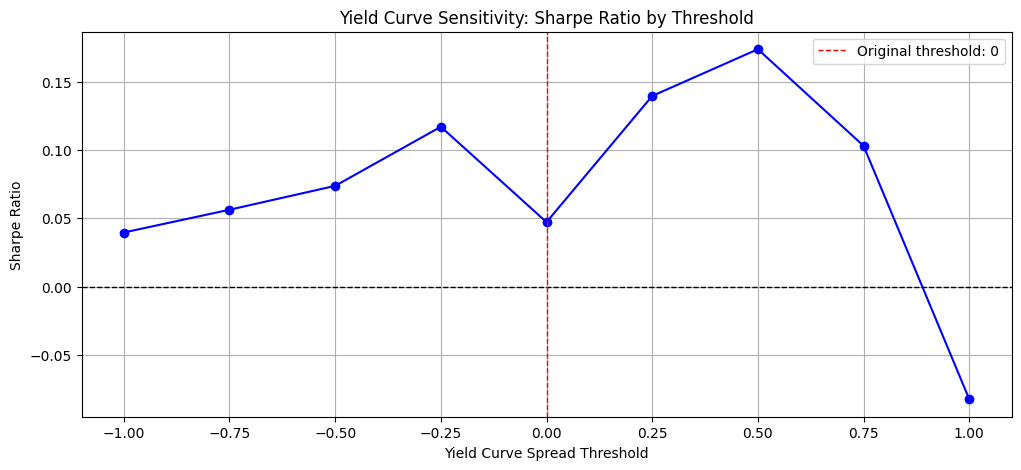


BEST THRESHOLD BY SHARPE RATIO
--------------------------------------------------------------------------------
   threshold  months_in_market  number_of_trades  total_return  \
6        0.5             127.0               7.0         48.15   

   annualized_return  annualized_volatility  sharpe_ratio  max_drawdown  \
6               2.42                  13.93          0.17        -32.07   

   calmar_ratio  
6          0.08  


In [17]:
# ============================================================
# YIELD CURVE THRESHOLD SENSITIVITY ANALYSIS

# Q3: the yield curve signal survive if we slightly change the threshold?
#
# Signal:
# US yield curve spread = 10-year Treasury yield - 2-year Treasury yield
#
# Strategy rule:
# Long HSI when yield curve spread > threshold
# Flat/cash when yield curve spread <= threshold
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -----------------------------
# 1. Helper function to load FRED data
# -----------------------------

def load_fred_series(series_id, start="2010-01-01"):
    """
    Downloads one time series from FRED.

    DGS10 = US 10-year Treasury yield
    DGS2 = US 2-year Treasury yield
    """

    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    data = pd.read_csv(url)

    data.columns = ["date", series_id]
    data["date"] = pd.to_datetime(data["date"])
    data = data.set_index("date")

    # FRED sometimes uses "." for missing values.
    data[series_id] = pd.to_numeric(data[series_id], errors="coerce")

    data = data.loc[start:]

    return data


# -----------------------------
# 2. Load US 10Y and 2Y yields
# -----------------------------

us10y = load_fred_series("DGS10")
us2y = load_fred_series("DGS2")

yields = pd.concat([us10y, us2y], axis=1)

yields = yields.rename(columns={
    "DGS10": "us_10y",
    "DGS2": "us_2y"
})

# Convert daily yield data to monthly.
# We use month-end values.
yields_monthly = yields.resample("M").last()

# Yield curve spread:
# Positive = normal curve.
# Negative = inverted curve.
yields_monthly["yield_curve_spread"] = (
    yields_monthly["us_10y"] - yields_monthly["us_2y"]
)


# -----------------------------
# 3. Load HSI monthly returns
# -----------------------------

hsi = yf.download(
    "^HSI",
    start="2010-01-01",
    auto_adjust=True
)["Close"]

if isinstance(hsi, pd.DataFrame):
    hsi = hsi.iloc[:, 0]

hsi = hsi.dropna()
hsi.name = "HSI_price"

hsi_monthly = hsi.resample("M").last().to_frame()

# Monthly HSI return.
hsi_monthly["HSI_return"] = hsi_monthly["HSI_price"].pct_change()


# -----------------------------
# 4. Combine into one dataframe
# -----------------------------

yc_df = pd.concat([hsi_monthly, yields_monthly], axis=1)

yc_df = yc_df.dropna()

print("YIELD CURVE DATAFRAME READY")
print("-" * 80)
print(yc_df.columns.tolist())
print(yc_df.tail())


# -----------------------------
# 5. Performance helper function
# -----------------------------

def calculate_performance(returns, periods_per_year=12):
    """
    Calculates strategy performance.

    returns:
    Monthly strategy returns.

    Total return:
    Full compounded return over sample.

    Annualized return:
    Average yearly compounded return.

    Annualized volatility:
    Yearly risk based on monthly volatility.

    Sharpe ratio:
    Annualized return divided by annualized volatility.

    Max drawdown:
    Worst peak-to-trough loss.

    Calmar ratio:
    Annualized return divided by absolute max drawdown.
    """

    returns = returns.dropna()

    if len(returns) == 0:
        return {
            "total_return": np.nan,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "max_drawdown": np.nan,
            "calmar_ratio": np.nan
        }

    equity_curve = (1 + returns).cumprod()

    total_return = equity_curve.iloc[-1] - 1

    years = len(returns) / periods_per_year

    annualized_return = (1 + total_return) ** (1 / years) - 1

    annualized_volatility = returns.std() * np.sqrt(periods_per_year)

    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else np.nan

    rolling_peak = equity_curve.cummax()
    drawdown = equity_curve / rolling_peak - 1
    max_drawdown = drawdown.min()

    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    return {
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown": max_drawdown,
        "calmar_ratio": calmar_ratio
    }


# -----------------------------
# 6. Threshold sensitivity test
# -----------------------------

# These thresholds are in percentage points.
# Example:
# threshold = 0 means normal rule:
# long HSI when 10Y - 2Y > 0.
thresholds = np.arange(-1.00, 1.01, 0.25)

sensitivity_results = []

for threshold in thresholds:

    temp = yc_df.copy()

    # Signal:
    # 1 = long HSI
    # 0 = cash
    temp["signal"] = np.where(
        temp["yield_curve_spread"] > threshold,
        1,
        0
    )

    # Shift by 1 month to avoid look-ahead bias.
    # We use this month's yield curve information to trade next month.
    temp["position"] = temp["signal"].shift(1)

    temp["strategy_return"] = temp["position"] * temp["HSI_return"]

    temp["trade"] = temp["position"].diff().abs()

    metrics = calculate_performance(temp["strategy_return"])

    sensitivity_results.append({
        "threshold": threshold,
        "months_in_market": temp["position"].sum(),
        "number_of_trades": temp["trade"].sum(),
        **metrics
    })

sensitivity_df = pd.DataFrame(sensitivity_results)


# -----------------------------
# 7. Buy-and-hold benchmark
# -----------------------------

buy_hold_metrics = calculate_performance(yc_df["HSI_return"])

print("\nBUY AND HOLD HSI BENCHMARK")
print("-" * 80)
print({
    "total_return": round(buy_hold_metrics["total_return"] * 100, 2),
    "annualized_return": round(buy_hold_metrics["annualized_return"] * 100, 2),
    "annualized_volatility": round(buy_hold_metrics["annualized_volatility"] * 100, 2),
    "sharpe_ratio": round(buy_hold_metrics["sharpe_ratio"], 2),
    "max_drawdown": round(buy_hold_metrics["max_drawdown"] * 100, 2),
    "calmar_ratio": round(buy_hold_metrics["calmar_ratio"], 2)
})


# -----------------------------
# 8. Format sensitivity output
# -----------------------------

display_sensitivity = sensitivity_df.copy()

percentage_cols = [
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "max_drawdown"
]

for col in percentage_cols:
    display_sensitivity[col] = display_sensitivity[col] * 100

display_sensitivity = display_sensitivity.round({
    "threshold": 2,
    "months_in_market": 0,
    "number_of_trades": 0,
    "total_return": 2,
    "annualized_return": 2,
    "annualized_volatility": 2,
    "sharpe_ratio": 2,
    "max_drawdown": 2,
    "calmar_ratio": 2
})

print("\nYIELD CURVE THRESHOLD SENSITIVITY ANALYSIS")
print("-" * 80)
print(display_sensitivity)


# -----------------------------
# 9. Plot Sharpe by threshold
# -----------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    sensitivity_df["threshold"],
    sensitivity_df["sharpe_ratio"],
    marker="o",
    color="blue"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="red", linestyle="--", linewidth=1, label="Original threshold: 0")

plt.title("Yield Curve Sensitivity: Sharpe Ratio by Threshold")
plt.xlabel("Yield Curve Spread Threshold")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# 10. Best threshold by Sharpe
# -----------------------------

best_by_sharpe = sensitivity_df.sort_values("sharpe_ratio", ascending=False).head(1)

best_display = best_by_sharpe.copy()

for col in percentage_cols:
    best_display[col] = best_display[col] * 100

best_display = best_display.round({
    "threshold": 2,
    "months_in_market": 0,
    "number_of_trades": 0,
    "total_return": 2,
    "annualized_return": 2,
    "annualized_volatility": 2,
    "sharpe_ratio": 2,
    "max_drawdown": 2,
    "calmar_ratio": 2
})

print("\nBEST THRESHOLD BY SHARPE RATIO")
print("-" * 80)
print(best_display)

Sensitivity analysis shows that the yield curve threshold rule modestly improves risk-adjusted performance versus buy-and-hold, especially around thresholds of 0.25 to 0.75 percentage points. The best threshold, 0.50, produced a Sharpe ratio of 0.17 versus 0.06 for buy-and-hold and reduced max drawdown from -55.34% to -32.07%. However, absolute performance remains weak, suggesting the yield curve is more useful as a risk-management filter than as a standalone return predictor.

## **Project Conclusion**

- This project tested whether the US yield curve can be used as a systematic macro signal for future Hang Seng Index returns. The main hypothesis was that an inverted or flatter US yield curve may predict weaker HSI returns because it can reflect tighter monetary policy, recession risk, weaker global risk appetite, and pressure on Asia-linked equity markets.

- Overall, the evidence was mixed. The yield curve signal showed some usefulness as a risk-management filter, but it did not appear strong enough to be treated as a standalone alpha signal. In the threshold sensitivity test, the best-performing rule was to be long HSI when the 10Y-2Y yield spread was above 0.50 percentage points. This produced a total return of 48.15%, annualized return of 2.42%, annualized volatility of 13.93%, Sharpe ratio of 0.17, and max drawdown of -32.07%. This was better than buy-and-hold HSI, which produced a total return of 23.71%, annualized return of 1.30%, annualized volatility of 19.97%, Sharpe ratio of 0.06, and max drawdown of -55.34%.

- The main improvement came from risk reduction rather than strong return generation. The yield curve strategy lowered volatility and reduced the worst drawdown compared with buy-and-hold, but the absolute Sharpe ratio remained low. This suggests that the yield curve may help identify periods when HSI exposure should be reduced, but it is not powerful enough on its own to justify a full trading strategy.

- Robustness testing also supported a cautious interpretation. The yield curve rule did not depend on only one exact threshold, since thresholds around 0.25 to 0.75 also showed some improvement versus buy-and-hold. However, the signal weakened when the threshold became too strict, and overall performance remained modest. Alternative macro signals such as credit spreads, VIX, and Fed funds variables did not robustly predict HSI returns. Cross-market tests showed that Fed funds level had a much stronger negative relationship with future KOSPI returns, especially after Newey-West adjustment and non-overlapping return checks, but this result did not transfer clearly to HSI.

- The final conclusion is that the US yield curve has limited predictive value for Hang Seng returns in this sample. It appears more useful as a macro risk filter than as a standalone return forecasting signal. A practical systematic strategy would likely need to combine the yield curve with other indicators, such as China-specific macro data, liquidity conditions, valuation, trend, or volatility regime filters.

- The main limitation of this project is that it uses relatively simple linear tests and free public data. Future work could improve the research by using non-overlapping out-of-sample backtests, adding China PMI or credit data, testing more robust position-sizing rules, including transaction costs more explicitly, and combining multiple macro signals into an ensemble model.